# Shot Prediction in the NBA: Analyzing the 2014-2015 Season

## Introduction

Basketball analytics has become an essential tool for understanding player performance and optimizing game strategy.  
This project aims to analyze shot attempts from the 2014-2015 NBA season to develop a predictive model for shot success.  
By leveraging real game data, the project seeks to identify key factors influencing shot outcomes, such as player positioning, game context, and temporal variables.

## Project Objective

The primary goal of this project is to predict whether a shot attempt will be successful based on a variety of contextual features. Specifically, we aim to:   
•	Analyze large-scale shot data from the 2014-2015 NBA season.   
•	Integrate play-by-play substitution data to track player time on the court.  
•	Develop a predictive model that evaluates the probability of a made shot based on relevant game conditions.

## Methodology and Tools

This project is implemented in Python, utilizing Jupyter Notebook as the primary development environment.  
The dataset contains approximately 200,000 shot attempts, enriched with additional computed features to enhance predictive accuracy.  
Key analytical steps include:  
-	Data Preprocessing:    
•	Extracting shot data and game events from the NBA API. 
•	Computing the absolute game time for each shot to standardize time representation.
•	Integrating player substitution data to calculate time on pitch (the duration a player has been on the court before attempting a shot). 
-	Feature Engineering:   
•	Incorporating spatial information (shot location, distance from the basket).   
•	Including temporal and game-state variables (quarter, remaining time, score differential).     
•	Analyzing player-specific factors (fatigue, shot frequency, past performance).     
-	Predictive Modeling:   
•	Exploring various machine learning techniques to classify shot attempts as successful or missed.       
•	Evaluating model performance using accuracy metrics and visualizations.

## Expected Outcomes

This study aims to provide insights into the key determinants of successful shots in basketball. By understanding how factors such as fatigue, game time, and player positioning influence shot outcomes, this project can contribute to better decision-making in real-time game strategy and player development.


Setup directories & import necessary libraies:

In [601]:
import os

#HOME_DIR = '/Users/yoav/Documents/Yoav/CS/20936 - DS Project/Shotpred'
HOME_DIR = '/Users/home/Shotpred'

DATA_DIR = os.path.join(HOME_DIR, 'data')
EXT_DATA_DIR = os.path.join(DATA_DIR, 'External')
INT_DATA_DIR = os.path.join(DATA_DIR, 'Internal')

import sys
#sys.path.append("/Users/yoav/0Documents/Yoav/CS/20936 - DS Project/Shotpred/utils")
sys.path.append("/Users/home/Shotpred/utils")


In [603]:
import pandas as pd
import os
from nba_api.stats.endpoints import playerindex, playbyplayv3

import data_utils as du

import importlib
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt


Upload the datasets of nba shots :

In [605]:
KAGGLE_SHOT_LOGS_201415_FILENAME = 'kaggle_shot_logs_2014_15.csv'
KAGGLE_SHOT_LOGS_201415_FULLPATH = os.path.join(EXT_DATA_DIR, KAGGLE_SHOT_LOGS_201415_FILENAME)
GENERAL_SHOT_LOGS_FILENAME = 'nba_2015_shots.csv'
GENERAL_SHOT_LOGS_FULLPATH = os.path.join(EXT_DATA_DIR, GENERAL_SHOT_LOGS_FILENAME)


Select the relevant columns from KAGGLE_COLS_FOR_MERGE :

In [607]:
KAGGLE_COLS_FOR_MERGE = ['GAME_ID', 'SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER', 'CLOSEST_DEFENDER_PLAYER_ID', 'CLOSE_DEF_DIST', 'player_id', 'absolute_game_time']

Read kaggle_shot_logs_2014_15 file,  
This file contains data such as defender distance, shot distance, number of dribbles, and more. and load it into a DataFrame named shot_logs_1415 :

In [609]:
shot_logs_1415 = pd.read_csv(KAGGLE_SHOT_LOGS_201415_FULLPATH)

In [12]:
#active_players_201415_ids = shot_logs_1415['player_id'].unique()

Calculates the absolute game time for each row in the shot_logs_1415 DataFrame using the function du.clock_to_absolute_seconds :

In [611]:
shot_logs_1415['absolute_game_time'] = shot_logs_1415.apply(lambda row: du.clock_to_absolute_seconds(row['GAME_CLOCK'], row['PERIOD']), axis=1)

In [612]:
shot_logs_1415.head()

,GAME_ID,MATCHUP,LOCATION,W,FINAL_MARGIN,SHOT_NUMBER,PERIOD,GAME_CLOCK,SHOT_CLOCK,DRIBBLES,...,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,FGM,PTS,player_name,player_id,absolute_game_time
0,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,1,1,1:09,10.8,2,...,2,made,"Anderson, Alan",101187,1.3,1,2,brian roberts,203148,651.0
1,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,2,1,0:14,3.4,0,...,3,missed,"Bogdanovic, Bojan",202711,6.1,0,0,brian roberts,203148,706.0
2,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,3,1,0:00,NaN,3,...,2,missed,"Bogdanovic, Bojan",202711,0.9,0,0,brian roberts,203148,720.0
3,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,4,2,11:47,10.3,2,...,2,missed,"Brown, Markel",203900,3.4,0,0,brian roberts,203148,733.0
4,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,5,2,10:34,10.9,2,...,2,missed,"Young, Thaddeus",201152,1.1,0,0,brian roberts,203148,806.0


Selecting the relevant columns from kaggle file :

In [615]:
kaggle_for_join = shot_logs_1415[KAGGLE_COLS_FOR_MERGE]

In [617]:
kaggle_for_join.head()

,GAME_ID,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,player_id,absolute_game_time
0,21400899,10.8,2,1.9,"Anderson, Alan",101187,1.3,203148,651.0
1,21400899,3.4,0,0.8,"Bogdanovic, Bojan",202711,6.1,203148,706.0
2,21400899,NaN,3,2.7,"Bogdanovic, Bojan",202711,0.9,203148,720.0
3,21400899,10.3,2,1.9,"Brown, Markel",203900,3.4,203148,733.0
4,21400899,10.9,2,2.7,"Young, Thaddeus",201152,1.1,203148,806.0


In [619]:
#active_players_career_stats = du.gather_mul_career_stats(active_players_201415_ids) # get the career stats for all active players in 2014-15 season

In [621]:
#active_players_cs_in_1415 = active_players_career_stats[active_players_career_stats['SEASON_ID'] == '2014-15'].reset_index(drop=True)
#active_players_cs_in_1415.to_csv(INT_DATA_DIR + 'active_players_career_stats_2014_15.csv', index=False)

Read file named 'active_players_career_stats_2014_15.csv',this file contains career stats of players that play in season 2014/2015 ,and loads it into a DataFrame named active_players_cs_in_1415 :

In [624]:
active_players_cs_in_1415 = pd.read_csv(os.path.join(INT_DATA_DIR, 'active_players_career_stats_2014_15.csv'))

Read file named 'nba_2015_shots.csv',this file contains general stats about the shot and the shooter, and loads it into a DataFrame named gen_sl :

In [627]:
gen_sl = pd.read_csv(GENERAL_SHOT_LOGS_FULLPATH)

In [629]:
gen_sl.shape

(205550, 26)

In [631]:
gen_sl.head()

,SEASON_1,SEASON_2,TEAM_ID,TEAM_NAME,PLAYER_ID,PLAYER_NAME,POSITION_GROUP,POSITION,GAME_DATE,GAME_ID,...,BASIC_ZONE,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT
0,2015,2014-15,1610612743,Denver Nuggets,203115,Will Barton,G,SG,04-15-2015,21401229,...,Restricted Area,Center,C,Less Than 8 ft.,-0.4,6.75,1,4,0,18
1,2015,2014-15,1610612744,Golden State Warriors,203949,James Michael McAdoo,F,PF,04-15-2015,21401229,...,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.35,0,4,0,22
2,2015,2014-15,1610612739,Cleveland Cavaliers,1890,Shawn Marion,F,SF,04-15-2015,21401225,...,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.35,0,5,0,3
3,2015,2014-15,1610612744,Golden State Warriors,203949,James Michael McAdoo,F,PF,04-15-2015,21401229,...,Restricted Area,Center,C,Less Than 8 ft.,-0.0,5.35,0,4,0,37
4,2015,2014-15,1610612743,Denver Nuggets,203475,Erick Green,G,PG,04-15-2015,21401229,...,Mid-Range,Left Side,L,16-24 ft.,16.9,14.85,19,4,0,48


Calculates the absolute game time for each row in the gen_sl DataFrame using the function du.clock_to_absolute_seconds :

In [634]:
gen_sl['absolute_game_time'] = gen_sl.apply(lambda row: du.clock_to_absolute_seconds(f"{str(row["MINS_LEFT"]).zfill(2)}:{str(row["SECS_LEFT"]).zfill(2)}", row['QUARTER']), axis=1)

Read file named 'nba_2014_2015_player_heights.csv',this file contains player's heights data,and loads it into a DataFrame named player_heights :

In [636]:
player_heights = pd.read_csv('/Users/home/Shotpred/data/Internal/nba_2014_2015_player_heights.csv')

In [637]:
player_heights.head()

,PLAYER_NAME,HEIGHT
0,AJ Price,6-2
1,Aaron Brooks,6-0
2,Aaron Gordon,6-8
3,Adreian Payne,6-10
4,Al Horford,6-9


Compares the unique game IDs in two datasets to determine how many unique games exist in each dataset and how many are share between them :

In [642]:
gen_sl_game_ids = set(gen_sl['GAME_ID'].unique())
kaggle_for_join_game_ids = set(kaggle_for_join['GAME_ID'].unique())

common_game_ids = gen_sl_game_ids.intersection(kaggle_for_join_game_ids)

print(f"Number of unique GAME_IDs in gen_sl: {len(gen_sl_game_ids)}")
print(f"Number of unique GAME_IDs in kaggle_for_join: {len(kaggle_for_join_game_ids)}")
print(f"Number of common GAME_IDs in both: {len(common_game_ids)}")

Number of unique GAME_IDs in gen_sl: 1230
Number of unique GAME_IDs in kaggle_for_join: 904
Number of common GAME_IDs in both: 904


Sorts the DataFrames by the absolute_game_time column in ascending order :

In [645]:
kaggle_for_join = kaggle_for_join.sort_values(by=['absolute_game_time']).reset_index(drop=True)

In [647]:
gen_sl = gen_sl.sort_values(by=['absolute_game_time']).reset_index(drop=True)
gen_sl['gen_sl_time_copy'] = gen_sl['absolute_game_time']

An asof merge between kaggle_for_join and gen_sl DataFrames based on the absolute_game_time column.
The pd.merge_asof function is particularly useful for time-based merging, ensuring that each row in kaggle_for_join is matched with the closest available row in gen_sl, within a specified time tolerance of 5 seconds :

In [650]:
merged = pd.merge_asof(kaggle_for_join, gen_sl, on='absolute_game_time',left_by=['player_id', 'GAME_ID'], right_by=['PLAYER_ID', 'GAME_ID'],  direction='nearest', suffixes=['_kaggle', '_shot_logs'], tolerance=5) #,left_by=['player_id', 'GAME_ID'], right_by=['PLAYER_ID', 'GAME_ID'], 

In [652]:
merged

,GAME_ID,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,player_id,absolute_game_time,SEASON_1,...,ZONE_NAME,ZONE_ABB,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT,gen_sl_time_copy
0,21400468,22.0,2,1.8,"Joseph, Cory",202709,2.3,2754,3.0,2015.0,...,Center,C,Less Than 8 ft.,-0.6,5.35,0.0,1.0,11.0,54.0,6.0
1,21400892,22.5,2,2.5,"Carroll, DeMarre",201960,3.5,2772,4.0,2015.0,...,Center,C,Less Than 8 ft.,-2.4,5.05,2.0,1.0,11.0,52.0,8.0
2,21400818,21.8,3,3.2,"Rose, Derrick",201565,5.3,202693,4.0,2015.0,...,Center,C,Less Than 8 ft.,1.5,6.45,1.0,1.0,11.0,51.0,9.0
3,21400292,21.1,0,1.3,"Fournier, Evan",203095,3.4,203463,4.0,2015.0,...,Center,C,Less Than 8 ft.,-2.2,6.65,2.0,1.0,11.0,54.0,6.0
4,21400855,20.6,0,0.0,"Ibaka, Serge",201586,4.0,202693,4.0,2015.0,...,Center,C,Less Than 8 ft.,-0.0,5.35,0.0,1.0,11.0,55.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128064,21400164,8.0,0,0.8,"Ilyasova, Ersan",101141,6.6,202711,5018.0,2015.0,...,Left Side Center,LC,24+ ft.,11.1,26.95,24.0,7.0,0.0,19.0,5021.0
128065,21400375,0.7,1,2.1,"Duncan, Tim",1495,9.8,201584,5023.0,2015.0,...,Left Side,L,16-24 ft.,19.4,11.65,20.0,7.0,0.0,17.0,5023.0
128066,21400164,NaN,0,0.8,"Antetokounmpo, Giannis",203507,3.9,2207,5030.0,2015.0,...,Right Side,R,16-24 ft.,-16.6,4.95,16.0,7.0,0.0,7.0,5033.0
128067,21400375,NaN,9,6.4,"Gasol, Marc",201188,5.1,1938,5035.0,2015.0,...,Right Side Center,RC,24+ ft.,-13.3,29.35,27.0,7.0,0.0,3.0,5037.0


In [654]:
merged.shape

(128069, 35)

Compare the values of absolute_game_time and gen_sl_time_copy :

In [657]:
(merged['absolute_game_time'] == merged['gen_sl_time_copy']).value_counts()

False    124704
True       3365
Name: count, dtype: int64

In [659]:
merged[['absolute_game_time','gen_sl_time_copy']].head()

,absolute_game_time,gen_sl_time_copy
0,3.0,6.0
1,4.0,8.0
2,4.0,9.0
3,4.0,6.0
4,4.0,5.0


Computes the difference between absolute_game_time and gen_sl_time_copy for each row :

In [662]:
(merged['absolute_game_time'] - merged['gen_sl_time_copy']).describe()

count    127303.000000
mean         -2.345986
std           1.003795
min          -5.000000
25%          -3.000000
50%          -2.000000
75%          -2.000000
max           5.000000
dtype: float64

The maximum difference between 'absolute_game_time' and 'gen_sl_time_copy' is 5 seconds,  
which is considered negligible and does not significantly impact the data.

In [665]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128069 entries, 0 to 128068
Data columns (total 35 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   GAME_ID                     128069 non-null  int64  
 1   SHOT_CLOCK                  122502 non-null  float64
 2   DRIBBLES                    128069 non-null  int64  
 3   TOUCH_TIME                  128069 non-null  float64
 4   CLOSEST_DEFENDER            128069 non-null  object 
 5   CLOSEST_DEFENDER_PLAYER_ID  128069 non-null  int64  
 6   CLOSE_DEF_DIST              128069 non-null  float64
 7   player_id                   128069 non-null  int64  
 8   absolute_game_time          128069 non-null  float64
 9   SEASON_1                    127303 non-null  float64
 10  SEASON_2                    127303 non-null  object 
 11  TEAM_ID                     127303 non-null  float64
 12  TEAM_NAME                   127303 non-null  object 
 13  PLAYER_ID     

In [667]:
##not_merged = merged[merged.gen_sl_time_copy.isna()]

In [669]:
##not_merged.head()

In [671]:
##not_merged.shape

# Add Time played column for each shot at merged dataFrame.
## calculations : 

In [674]:
from nba_api.stats.endpoints import playerindex, playbyplayv3 


Retrieves NBA game data for the 2014-15 season using the LeagueGameFinder function from the nba_api.
It extracts key game details and stores them in a DataFrame 


In [677]:
from nba_api.stats.endpoints import LeagueGameFinder
import pandas as pd

game_finder = LeagueGameFinder(season_nullable='2014-15', league_id_nullable='00')
games = game_finder.get_data_frames()[0]

games_df = games[['GAME_ID', 'GAME_DATE', 'MATCHUP']]
print(games_df.head(10))


      GAME_ID   GAME_DATE      MATCHUP
0  0041400406  2015-06-16  CLE vs. GSW
1  0041400406  2015-06-16    GSW @ CLE
2  0041400405  2015-06-14  GSW vs. CLE
3  0041400405  2015-06-14    CLE @ GSW
4  0041400404  2015-06-11    GSW @ CLE
5  0041400404  2015-06-11  CLE vs. GSW
6  0041400403  2015-06-09  CLE vs. GSW
7  0041400403  2015-06-09    GSW @ CLE
8  0041400402  2015-06-07    CLE @ GSW
9  0041400402  2015-06-07  GSW vs. CLE


Get all 904 games  stats from api and save into dict  game_stats


Add column time played  to merged data :

In [681]:
from nba_api.stats.endpoints import PlayByPlayV2
import time

def process_game_stats(df_merged):
    """
    Process play-by-play data for each unique game ID in the dataframe.
    
    Parameters:
    df_merged (pandas.DataFrame): DataFrame containing GAME_ID column
    
    Returns:
    dict: Dictionary with game IDs as keys and play-by-play DataFrames as values
    """
    # Get unique game IDs
    unique_games = df_merged['GAME_ID'].unique()
    
    # Dictionary to store results
    results = {}
    
    # Process each game
    for game_id in unique_games:

        print(f"Processing game ID: {game_id}")
        
        try:
            # Call API
            pbp = PlayByPlayV2(game_id='00' + str(game_id))
            pbp_df = pbp.get_data_frames()[0]
            
            # Filter for EVENTMSGTYPE == 8
            pbp_df = pbp_df[pbp_df['EVENTMSGTYPE'] == 8]
            
            # Store in results dictionary
            results[game_id] = pbp_df
            
            # Add delay to avoid hitting API rate limits
            time.sleep(1)
            
        except Exception as e:
            print(f"Error processing game {game_id}: {str(e)}")
            continue
    
    return results

Processes the 'merged' DataFrame to generate game statistics using the 'process_game_stats' function:

In [685]:
game_stats = process_game_stats(merged)

# Access individual game data
for game_id, game_df in game_stats.items():
    print(f"\nGame {game_id} has {len(game_df)} events")

Processing game ID: 21400468
Processing game ID: 21400892
Processing game ID: 21400818
Processing game ID: 21400292
Processing game ID: 21400855
Processing game ID: 21400251
Processing game ID: 21400459
Processing game ID: 21400162
Processing game ID: 21400869
Processing game ID: 21400790
Processing game ID: 21400305
Processing game ID: 21400687
Processing game ID: 21400903
Processing game ID: 21400883
Processing game ID: 21400772
Processing game ID: 21400639
Processing game ID: 21400808
Processing game ID: 21400200
Processing game ID: 21400111
Processing game ID: 21400774
Processing game ID: 21400543
Processing game ID: 21400131
Processing game ID: 21400513
Processing game ID: 21400199
Processing game ID: 21400802
Processing game ID: 21400612
Processing game ID: 21400384
Processing game ID: 21400861
Processing game ID: 21400423
Processing game ID: 21400826
Processing game ID: 21400816
Processing game ID: 21400257
Processing game ID: 21400355
Processing game ID: 21400839
Processing gam

Check if game_stats contains all the data :


In [686]:
if not game_stats:
    print("❌ Extraction failed! `game_stats` is empty.")
else:
    print(f"✅ Extraction successful! {len(game_stats)} games processed.")


✅ Extraction successful! 904 games processed.


In [687]:
#print(game_stats.columns)  # Show all column names
game_id = list(game_stats.keys())[0]  # בוחר את המשחק הראשון ברשימה
pbp_df = game_stats[game_id]  # מחלץ את הנתונים של המשחק
print(pbp_df.columns)  # בודק את שמות העמודות


Index(['GAME_ID', 'EVENTNUM', 'EVENTMSGTYPE', 'EVENTMSGACTIONTYPE', 'PERIOD',
       'WCTIMESTRING', 'PCTIMESTRING', 'HOMEDESCRIPTION', 'NEUTRALDESCRIPTION',
       'VISITORDESCRIPTION', 'SCORE', 'SCOREMARGIN', 'PERSON1TYPE',
       'PLAYER1_ID', 'PLAYER1_NAME', 'PLAYER1_TEAM_ID', 'PLAYER1_TEAM_CITY',
       'PLAYER1_TEAM_NICKNAME', 'PLAYER1_TEAM_ABBREVIATION', 'PERSON2TYPE',
       'PLAYER2_ID', 'PLAYER2_NAME', 'PLAYER2_TEAM_ID', 'PLAYER2_TEAM_CITY',
       'PLAYER2_TEAM_NICKNAME', 'PLAYER2_TEAM_ABBREVIATION', 'PERSON3TYPE',
       'PLAYER3_ID', 'PLAYER3_NAME', 'PLAYER3_TEAM_ID', 'PLAYER3_TEAM_CITY',
       'PLAYER3_TEAM_NICKNAME', 'PLAYER3_TEAM_ABBREVIATION',
       'VIDEO_AVAILABLE_FLAG'],
      dtype='object')


In [689]:
def convert_time_to_seconds(time_str):
    """ ממיר זמן בפורמט MM:SS לשניות """
    minutes, seconds = map(int, time_str.split(":"))
    return minutes * 60 + seconds

def compute_absolute_time(df):
    """ מחשב זמן מוחלט למשחק על בסיס PERIOD ו-PCTIMESTRING """
    df = df.copy()
    
    #Convert time left in quarter to seconds
    df['SECONDS_LEFT_IN_Q'] = df['PCTIMESTRING'].apply(convert_time_to_seconds)
    
    #Calculate every quarter
    df['ABS_TIME'] = (df['PERIOD'] - 1) * 720 + (720 - df['SECONDS_LEFT_IN_Q'])
    
    return df

# הפעלת הפונקציה על ה- DataFrame שלך
pbp_df = compute_absolute_time(pbp_df)

for game_id in game_stats.keys():
    game_stats[game_id] = compute_absolute_time(game_stats[game_id])  # עדכון כל משחק בנפרד


import pandas as pd

# המרת המילון של המשחקים ל- DataFrame יחיד
game_stats = pd.concat(game_stats.values(), ignore_index=True)

# הצגת עמודות לבדיקה
print("Columns in game_stats:", game_stats.columns)


game_stats = compute_absolute_time(game_stats)

# בדיקה שהחישוב עבד
print(game_stats[['PCTIMESTRING', 'SECONDS_LEFT_IN_Q', 'ABS_TIME']].head())


print(game_stats.head())


Function which calculated minutes_played by game state and player name and absolute time :

In [742]:
def calculate_minutes_played(play_by_play_df, until_clock, player_name):
    
    """
    Calculates the number of minutes played by each player until the given clock timestamp.
    """
    
    play_by_play_df = compute_absolute_time(play_by_play_df)

    # Parse until_clock into a timedelta for comparison
    #until_time = Timedelta(until_clock, unit='s')

    # Sort the data by period and actionNumber to simulate the game progression
    play_by_play_df = play_by_play_df.sort_values(by=['PERIOD', 'EVENTNUM']).reset_index(drop=True)

    # Track active players on the court for each team
    active_players = {}
    total_play_time = {}

    # Filter out substitution events
    sub_events = play_by_play_df[(play_by_play_df['EVENTMSGTYPE'] == 8) & (play_by_play_df['ABS_TIME'] <= until_clock)].reset_index(drop=True)

    # 🔹 Adding the starting five
    starting_players = set()

    for _, row in play_by_play_df.iterrows():
        if row['EVENTMSGTYPE'] == 8:  # stop in the first sub
            break
        if pd.notna(row['PLAYER1_NAME']):  
            starting_players.add((row['PLAYER1_NAME'], row.get('PLAYER1_TEAM_ABBREVIATION', 'Unknown')))

    # Adding starting players with time 0 (they started playing from the first second of the game)
    for player, team in starting_players:
        if team not in active_players:
            active_players[team] = {}
        active_players[team][player] = 0 
        
#     print("The starting 5 :", starting_players)


    for _, row in sub_events.iterrows():
        current_time = row['ABS_TIME']
#         print(current_time)

        player_in = row['PLAYER2_NAME']  
        player_out = row['PLAYER1_NAME'] 


        # Handle substitution logic for active players
        team = row.get('PLAYER1_TEAM_ABBREVIATION', 'Unknown')  
#       print(f"🔄 חילוף: {player_out} → {player_in} בקבוצה {team} בזמן {current_time}")  
        
        if team not in active_players:
            active_players[team] = {}

        # Record play time for the player being substituted out
        if player_out in active_players[team]:
            play_start_time = active_players[team].pop(player_out)
            minutes_played = (current_time - play_start_time) / 60
            total_play_time[player_out] = total_play_time.get(player_out, 0) + minutes_played
#             print(f"🕒 {player_out} שיחק {minutes_played:.2f} דקות")  


        # Add the substituted-in player to active players
        active_players[team][player_in] = current_time

    # Add remaining play times for players still on the court
    for team, players in active_players.items():
        for player, play_start_time in players.items():
            #minutes_played = (until_time - play_start_time).total_seconds() / 60
            minutes_played = (until_clock - play_start_time) / 60
            total_play_time[player] = total_play_time.get(player, 0) + minutes_played

    return total_play_time.get(player_name, np.nan)


# בוחרים משחק ספציפי
game_id = game_stats.iloc[0]['GAME_ID']  # קבלת ה-GAME_ID הראשון
pbp_df = game_stats[game_stats['GAME_ID'] == game_id]  # קבלת הנתונים של המשחק

# בוחרים שחקן ספציפי מהמשחק
player_name = pbp_df['PLAYER1_NAME'].dropna().unique()[0]  # השחקן הראשון עם שם לא ריק

# מחשבים זמן משחק עבור השחקן
total_play_time = calculate_minutes_played(pbp_df, until_clock=2880, player_name=player_name)

# הדפסת התוצאה
print(f"✅ Function executed for GAME_ID {game_id}")
print(f"🔹 {player_name} played {total_play_time.get(player_name, 0):.2f} minutes until 2880 seconds")


In [754]:
print(type(total_play_time))
print(total_play_time)


<class 'dict'>
{'Jarnell Stokes': 3.9833333333333334, 'Matt Bonner': 14.966666666666665, 'Manu Ginobili': 26.666666666666668, 'Patty Mills': 15.316666666666666, 'Aron Baynes': 6.15, 'Tayshaun Prince': 28.266666666666666, 'Jon Leuer': 0.36666666666666664, 'Danny Green': 16.816666666666666, 'Jeff Ayres': 13.3, 'Vince Carter': 17.78333333333333, 'Boris Diaw': 10.55, 'Cory Joseph': 17.066666666666666, 'Tony Allen': 18.866666666666667, 'Tim Duncan': 19.166666666666668, 'Mike Conley': 20.683333333333334, 'Marco Belinelli': 21.233333333333334, 'Beno Udrih': 7.116666666666666, 'Quincy Pondexter': 9.283333333333333, 'Marc Gasol': 6.55, 'Courtney Lee': 1.9666666666666666, 'Jordan Adams': 0.26666666666666666, 'Austin Daye': 2.7666666666666666}


Run function above for each row in merged data and add column time_played into merged

🔍 Testing for GAME_ID: 21400468, PLAYER_NAME: Tony Allen, absolute_game_time: 3.0
⏳ Player Tony Allen in game 21400468 played: nan minutes


In [750]:
# 🔹 Manually select a different game and player
game_id = 21400468  # Replace with the desired GAME_ID
player_name = "LeBron James"  # Replace with the desired player name
absolute_game_time = 600  # Replace with a different game time (in seconds)

print(f"🔍 Testing for GAME_ID: {game_id}, PLAYER_NAME: {player_name}, absolute_game_time: {absolute_game_time}")

if game_id in game_stats:
    test_result = calculate_minutes_played(game_stats[game_id], absolute_game_time, player_name)
    print(f"⏳ Player {player_name} in game {game_id} played: {test_result} minutes")
else:
    print(f"⚠️ GAME_ID {game_id} not found in game_stats")


🔍 Testing for GAME_ID: 21400468, PLAYER_NAME: LeBron James, absolute_game_time: 600
⏳ Player LeBron James in game 21400468 played: nan minutes


In [746]:
import numpy as np
import pandas as pd
from tqdm import tqdm



def calculate_time_played_for_all(df_merged, game_stats):
    time_played_list = []
    # Initialize tqdm with total number of rows and a descriptive message
    for idx, row in tqdm(df_merged.iterrows(), total=len(df_merged), desc="Calculating time played"):
        try:
            game_id = row['GAME_ID']
            player_name = row['PLAYER_NAME']
            
            if game_id not in game_stats:
                time_played_list.append(np.nan)
                continue

            time_played = calculate_minutes_played(
                game_stats[game_id], 
                row['absolute_game_time'],
                player_name
            )
            time_played_list.append(time_played)
           

        
        except Exception as e:
            print(f"Error at row {idx} | GAME_ID: {game_id} | PLAYER_NAME: {player_name} | Error: {str(e)}")
            time_played_list.append(np.nan)

    return pd.Series(time_played_list, index=df_merged.index)
    

In [720]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def calculate_time_played_for_all(df_merged, game_stats):
    time_played_list = []

    for idx, row in tqdm(df_merged.iterrows(), total=len(df_merged), desc="Calculating time played"):
        try:
            game_id = row['GAME_ID']
            player_name = row['PLAYER_NAME']

            if game_id not in game_stats:
                time_played_list.append(np.nan)
                continue

            # Call the function to get the time played
            time_played_dict = calculate_minutes_played(
                game_stats[game_id], 
                row['absolute_game_time'],
                player_name
            )

            # ✅ Ensure we store only the number (not a dictionary)
            if isinstance(time_played_dict, dict):  
                time_played_value = time_played_dict.get(player_name, np.nan)
            else:
                time_played_value = time_played_dict  # Already a number

            time_played_list.append(time_played_value)

        except Exception as e:
            print(f"Error at row {idx} | GAME_ID: {game_id} | PLAYER_NAME: {player_name} | Error: {str(e)}")
            time_played_list.append(np.nan)

    return pd.Series(time_played_list, index=df_merged.index)


Add time_played column to merged dataFrame :

In [748]:
merged['time_played'] = calculate_time_played_for_all(merged, game_stats)


Calculating time played: 100%|█████████| 128069/128069 [09:48<00:00, 217.52it/s]


In [770]:
print("First 10 values of time_played:\n", merged['time_played'].head(10))
print("Missing values in time_played:", merged['time_played'].isna().sum())
print("Data type of time_played:", merged['time_played'].dtype)
      
valid_values_count = merged['time_played'].notna().sum()
print(f"✅ Number of non-missing values in time_played: {valid_values_count}")

# אם יש לפחות ערך תקין אחד, הדפס דוגמאות
if valid_values_count > 0:
    print("🔹 Example of non-missing values in time_played:")
    print(merged['time_played'].dropna().head(10))  # הצגת 10 הערכים הראשונים שאינם NaN
else:
    print("⚠️ No valid values found in time_played (all are NaN)")



First 10 values of time_played:
 0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: time_played, dtype: float64
Missing values in time_played: 36329
Data type of time_played: float64
✅ Number of non-missing values in time_played: 91740
🔹 Example of non-missing values in time_played:
5712    0.483333
6498    0.900000
6691    0.116667
6951    1.616667
7761    0.300000
7959    0.400000
8031    0.750000
8072    1.266667
8080    0.266667
8346    0.200000
Name: time_played, dtype: float64


Add time played in seconds :

In [776]:
mean_time_played = merged['time_played'].mean()  # מחשב את הממוצע של העמודה
merged['time_played'].fillna(mean_time_played, inplace=True)  # ממלא את NaN בממוצע

# ✅ בדיקה: הדפסת מספר הערכים החסרים אחרי המילוי
print(f"✅ Missing values in time_played after filling: {merged['time_played'].isna().sum()}")


✅ Missing values in time_played after filling: 0


In [778]:
merged['time_played_seconds'] = merged['time_played']*60 

In [780]:
merged.head()

,GAME_ID,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,player_id,absolute_game_time,SEASON_1,...,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT,gen_sl_time_copy,time_played,time_played_seconds
0,21400468,22.0,2,1.8,"Joseph, Cory",202709,2.3,2754,3.0,2015.0,...,Less Than 8 ft.,-0.6,5.35,0.0,1.0,11.0,54.0,6.0,10.017653,601.059167
1,21400892,22.5,2,2.5,"Carroll, DeMarre",201960,3.5,2772,4.0,2015.0,...,Less Than 8 ft.,-2.4,5.05,2.0,1.0,11.0,52.0,8.0,10.017653,601.059167
2,21400818,21.8,3,3.2,"Rose, Derrick",201565,5.3,202693,4.0,2015.0,...,Less Than 8 ft.,1.5,6.45,1.0,1.0,11.0,51.0,9.0,10.017653,601.059167
3,21400292,21.1,0,1.3,"Fournier, Evan",203095,3.4,203463,4.0,2015.0,...,Less Than 8 ft.,-2.2,6.65,2.0,1.0,11.0,54.0,6.0,10.017653,601.059167
4,21400855,20.6,0,0.0,"Ibaka, Serge",201586,4.0,202693,4.0,2015.0,...,Less Than 8 ft.,-0.0,5.35,0.0,1.0,11.0,55.0,5.0,10.017653,601.059167


In [782]:
merged.shape

(128069, 37)

In [784]:
merged.columns

Index(['GAME_ID', 'SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER',
       'CLOSEST_DEFENDER_PLAYER_ID', 'CLOSE_DEF_DIST', 'player_id',
       'absolute_game_time', 'SEASON_1', 'SEASON_2', 'TEAM_ID', 'TEAM_NAME',
       'PLAYER_ID', 'PLAYER_NAME', 'POSITION_GROUP', 'POSITION', 'GAME_DATE',
       'HOME_TEAM', 'AWAY_TEAM', 'EVENT_TYPE', 'SHOT_MADE', 'ACTION_TYPE',
       'SHOT_TYPE', 'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE',
       'LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'MINS_LEFT', 'SECS_LEFT',
       'gen_sl_time_copy', 'time_played', 'time_played_seconds'],
      dtype='object')

In [786]:
merged

,GAME_ID,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,player_id,absolute_game_time,SEASON_1,...,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT,gen_sl_time_copy,time_played,time_played_seconds
0,21400468,22.0,2,1.8,"Joseph, Cory",202709,2.3,2754,3.0,2015.0,...,Less Than 8 ft.,-0.6,5.35,0.0,1.0,11.0,54.0,6.0,10.017653,601.059167
1,21400892,22.5,2,2.5,"Carroll, DeMarre",201960,3.5,2772,4.0,2015.0,...,Less Than 8 ft.,-2.4,5.05,2.0,1.0,11.0,52.0,8.0,10.017653,601.059167
2,21400818,21.8,3,3.2,"Rose, Derrick",201565,5.3,202693,4.0,2015.0,...,Less Than 8 ft.,1.5,6.45,1.0,1.0,11.0,51.0,9.0,10.017653,601.059167
3,21400292,21.1,0,1.3,"Fournier, Evan",203095,3.4,203463,4.0,2015.0,...,Less Than 8 ft.,-2.2,6.65,2.0,1.0,11.0,54.0,6.0,10.017653,601.059167
4,21400855,20.6,0,0.0,"Ibaka, Serge",201586,4.0,202693,4.0,2015.0,...,Less Than 8 ft.,-0.0,5.35,0.0,1.0,11.0,55.0,5.0,10.017653,601.059167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128064,21400164,8.0,0,0.8,"Ilyasova, Ersan",101141,6.6,202711,5018.0,2015.0,...,24+ ft.,11.1,26.95,24.0,7.0,0.0,19.0,5021.0,10.017653,601.059167
128065,21400375,0.7,1,2.1,"Duncan, Tim",1495,9.8,201584,5023.0,2015.0,...,16-24 ft.,19.4,11.65,20.0,7.0,0.0,17.0,5023.0,66.166667,3970.000000
128066,21400164,NaN,0,0.8,"Antetokounmpo, Giannis",203507,3.9,2207,5030.0,2015.0,...,16-24 ft.,-16.6,4.95,16.0,7.0,0.0,7.0,5033.0,60.950000,3657.000000
128067,21400375,NaN,9,6.4,"Gasol, Marc",201188,5.1,1938,5035.0,2015.0,...,24+ ft.,-13.3,29.35,27.0,7.0,0.0,3.0,5037.0,18.166667,1090.000000


Save to csv file :

In [788]:
merged.to_csv('merged.csv',index=False)

# END of Time played calculations.

## Add Attacker's and defender's heights to the data by player id:

In [790]:
player_heights.head()

,PLAYER_NAME,HEIGHT
0,AJ Price,6-2
1,Aaron Brooks,6-0
2,Aaron Gordon,6-8
3,Adreian Payne,6-10
4,Al Horford,6-9


convert the heights to float :

In [792]:
player_heights['HEIGHT'] = player_heights['HEIGHT'].str.replace('-', '.').astype(float)


In [794]:
player_heights.head()

,PLAYER_NAME,HEIGHT
0,AJ Price,6.2
1,Aaron Brooks,6.0
2,Aaron Gordon,6.8
3,Adreian Payne,6.1
4,Al Horford,6.9


Merge the player_heights DataFrame with the merged DataFrame to add PLAYER_ID to player_heights :

In [796]:
player_heights = player_heights.merge(
    merged[['PLAYER_NAME', 'PLAYER_ID']],
    on='PLAYER_NAME',
    how='left'
)

Remove duplicates so each player appears only once

In [798]:
player_heights = player_heights.drop_duplicates(subset=['PLAYER_ID'])

Convert PLAYER_ID from float to int.
Using Int64 to handle any missing values (NaN) :

In [800]:
player_heights['PLAYER_ID'] = player_heights['PLAYER_ID'].astype('Int64')

In [802]:
player_heights.head()

,PLAYER_NAME,HEIGHT,PLAYER_ID
0,AJ Price,6.2,<NA>
1,Aaron Brooks,6.0,201166
557,Aaron Gordon,6.8,203932
660,Al Horford,6.9,201143
1370,Al Jefferson,6.1,2744


checks for missing values and fills any missing values in the HEIGHT column with the mean height of all players.

In [804]:
player_heights.isna().sum()

PLAYER_NAME    0
HEIGHT         2
PLAYER_ID      1
dtype: int64

In [806]:
player_heights['HEIGHT'] = player_heights['HEIGHT'].fillna(player_heights['HEIGHT'].mean())

In [808]:
player_heights.isna().sum()

PLAYER_NAME    0
HEIGHT         0
PLAYER_ID      1
dtype: int64

In [810]:
merged['PLAYER_ID'].isna().sum()

766

Unmerged values :

In [813]:
merged[merged['PLAYER_ID'].isna()]

,GAME_ID,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,player_id,absolute_game_time,SEASON_1,...,ZONE_RANGE,LOC_X,LOC_Y,SHOT_DISTANCE,QUARTER,MINS_LEFT,SECS_LEFT,gen_sl_time_copy,time_played,time_played_seconds
182,21400345,11.6,2,5.0,"Conley, Mike",201144,0.3,203487,13.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.017653,601.059167
188,21400471,22.9,0,2.1,"Hill, Jordan",201941,2.6,202389,13.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.017653,601.059167
220,21400872,11.2,0,0.0,"Amundson, Lou",200811,3.7,202685,14.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.017653,601.059167
246,21400322,10.9,0,4.6,"Joseph, Cory",202709,2.9,101181,14.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.017653,601.059167
379,21400515,9.6,5,4.1,"Holiday, Jrue",201950,5.7,202322,16.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.017653,601.059167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127147,21400307,24.0,0,3.2,"Griffin, Blake",201933,2.3,200782,3379.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.017653,601.059167
127490,21400288,7.7,1,3.0,"Sims, Henry",203156,3.5,203484,3502.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.017653,601.059167
127583,21400496,9.6,1,1.5,"Gasol, Pau",2200,2.3,202323,3532.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.017653,601.059167
127867,21400302,17.3,0,0.0,"Turner, Evan",202323,5.4,101162,4049.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.017653,601.059167


In [815]:
##merged.dropna(inplace=True) # temporarily delete rows with empty values

In [817]:
# Remove only rows that contain missing values in any column
##merged = merged.dropna().reset_index(drop=True)
##print(f"Rows after removing missing values: {len(merged)}")


In [819]:
# Fill missing values in numeric columns with their respective column mean
numeric_cols = merged.select_dtypes(include=['number']).columns
merged[numeric_cols] = merged[numeric_cols].fillna(merged[numeric_cols].mean())

# Display remaining missing values (should be 0 for numeric columns)
print("Remaining missing values in numeric columns:", merged[numeric_cols].isna().sum().sum())


Remaining missing values in numeric columns: 0


In [821]:
# Fill missing values in categorical columns with the most frequent value
categorical_cols = merged.select_dtypes(include=['object']).columns
for col in categorical_cols:
    merged[col] = merged[col].fillna(merged[col].mode()[0])


/var/folders/fh/lr2n8w4x2hlcn416x09v4d6m0000gn/T/ipykernel_13087/4012634952.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged[col] = merged[col].fillna(merged[col].mode()[0])


In [823]:
(merged['player_id'] != merged['PLAYER_ID'] ).sum()

766

In [825]:
merged.shape

(128069, 37)

In [827]:
merged['PLAYER_ID'] = merged['PLAYER_ID'].astype('int64')

In [829]:
player_heights.dtypes

PLAYER_NAME     object
HEIGHT         float64
PLAYER_ID        Int64
dtype: object

In [831]:
merged.dtypes

GAME_ID                         int64
SHOT_CLOCK                    float64
DRIBBLES                        int64
TOUCH_TIME                    float64
CLOSEST_DEFENDER               object
CLOSEST_DEFENDER_PLAYER_ID      int64
CLOSE_DEF_DIST                float64
player_id                       int64
absolute_game_time            float64
SEASON_1                      float64
SEASON_2                       object
TEAM_ID                       float64
TEAM_NAME                      object
PLAYER_ID                       int64
PLAYER_NAME                    object
POSITION_GROUP                 object
POSITION                       object
GAME_DATE                      object
HOME_TEAM                      object
AWAY_TEAM                      object
EVENT_TYPE                     object
SHOT_MADE                        bool
ACTION_TYPE                    object
SHOT_TYPE                      object
BASIC_ZONE                     object
ZONE_NAME                      object
ZONE_ABB    

In [833]:
# Merge for attacker heights
merged_with_attacker_heights = pd.merge(merged, player_heights, left_on='player_id', right_on='PLAYER_ID', suffixes=('', '_attacker'))
# Check for missing values in attacker height
print("Columns in merged_with_attacker_heights:", merged_with_attacker_heights.columns)
merged_with_attacker_heights.isna().sum()

# !!!!!!Merge for defender heights - CAUSES NULL VALUES BECAUSE OF THE DIFFERENT PLAYER NAMES AND LEFT JOIN - NEED IDS!!!!!
merged_with_both_heights = pd.merge(merged_with_attacker_heights, player_heights, left_on='CLOSEST_DEFENDER_PLAYER_ID', right_on='PLAYER_ID', suffixes=('', '_defender'), how='left')

# Drop the extra PLAYER_NAME column from the second merge
merged_with_both_heights = merged_with_both_heights.drop(columns=['PLAYER_ID_defender','PLAYER_NAME_defender',])

Columns in merged_with_attacker_heights: Index(['GAME_ID', 'SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER',
       'CLOSEST_DEFENDER_PLAYER_ID', 'CLOSE_DEF_DIST', 'player_id',
       'absolute_game_time', 'SEASON_1', 'SEASON_2', 'TEAM_ID', 'TEAM_NAME',
       'PLAYER_ID', 'PLAYER_NAME', 'POSITION_GROUP', 'POSITION', 'GAME_DATE',
       'HOME_TEAM', 'AWAY_TEAM', 'EVENT_TYPE', 'SHOT_MADE', 'ACTION_TYPE',
       'SHOT_TYPE', 'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE',
       'LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'MINS_LEFT', 'SECS_LEFT',
       'gen_sl_time_copy', 'time_played', 'time_played_seconds',
       'PLAYER_NAME_attacker', 'HEIGHT', 'PLAYER_ID_attacker'],
      dtype='object')


Check for Unmatched defenders :

In [835]:
unmatched_defenders = merged_with_attacker_heights[
    ~merged_with_attacker_heights['CLOSEST_DEFENDER_PLAYER_ID'].isin(player_heights['PLAYER_ID'])
]
print(f"Unmatched defenders: {len(unmatched_defenders)}")


Unmatched defenders: 21773


In [837]:
merged_with_both_heights.isna().sum()

GAME_ID                           0
SHOT_CLOCK                        0
DRIBBLES                          0
TOUCH_TIME                        0
CLOSEST_DEFENDER                  0
CLOSEST_DEFENDER_PLAYER_ID        0
CLOSE_DEF_DIST                    0
player_id                         0
absolute_game_time                0
SEASON_1                          0
SEASON_2                          0
TEAM_ID                           0
TEAM_NAME                         0
PLAYER_ID                         0
PLAYER_NAME                       0
POSITION_GROUP                    0
POSITION                          0
GAME_DATE                         0
HOME_TEAM                         0
AWAY_TEAM                         0
EVENT_TYPE                        0
SHOT_MADE                         0
ACTION_TYPE                       0
SHOT_TYPE                         0
BASIC_ZONE                        0
ZONE_NAME                         0
ZONE_ABB                          0
ZONE_RANGE                  

Deside to fill the average of height_defenders :

In [839]:
merged_with_both_heights['HEIGHT_defender'] = merged_with_both_heights['HEIGHT_defender'].fillna(merged_with_both_heights['HEIGHT_defender'].mean())


In [841]:
merged_with_both_heights.isna().sum()

GAME_ID                       0
SHOT_CLOCK                    0
DRIBBLES                      0
TOUCH_TIME                    0
CLOSEST_DEFENDER              0
CLOSEST_DEFENDER_PLAYER_ID    0
CLOSE_DEF_DIST                0
player_id                     0
absolute_game_time            0
SEASON_1                      0
SEASON_2                      0
TEAM_ID                       0
TEAM_NAME                     0
PLAYER_ID                     0
PLAYER_NAME                   0
POSITION_GROUP                0
POSITION                      0
GAME_DATE                     0
HOME_TEAM                     0
AWAY_TEAM                     0
EVENT_TYPE                    0
SHOT_MADE                     0
ACTION_TYPE                   0
SHOT_TYPE                     0
BASIC_ZONE                    0
ZONE_NAME                     0
ZONE_ABB                      0
ZONE_RANGE                    0
LOC_X                         0
LOC_Y                         0
SHOT_DISTANCE                 0
QUARTER 

In [843]:
merged_with_both_heights.shape

(125289, 41)

Add player's career shot stats and rellavant colums for prediction to COLS_FOR_PRED :

In [845]:
#COLS_FOR_PRED = ['SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER_PLAYER_ID', 'CLOSE_DEF_DIST', 'absolute_game_time', 'SEASON_1', 'SEASON_2', 'TEAM_ID', 'PLAYER_ID', 'POSITION_GROUP', 'POSITION', 'GAME_DATE', 'HOME_TEAM', 'AWAY_TEAM', 'SHOT_MADE', 'ACTION_TYPE', 'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE', 'LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'MINS_LEFT', 'SECS_LEFT', 'HEIGHT', 'HEIGHT_defender']
COLS_FOR_PRED = ['SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER_PLAYER_ID', 'CLOSE_DEF_DIST', 'absolute_game_time', 'SEASON_1', 'TEAM_ID', 'PLAYER_ID', 'POSITION_GROUP', 'POSITION', 'HOME_TEAM', 'AWAY_TEAM', 'SHOT_MADE', 'ACTION_TYPE', 'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE', 'LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'HEIGHT', 'HEIGHT_defender', 'time_played_seconds']
CAREER_STATS_COL_FOR_MERGE = ['FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'PLAYER_ID'] #already filtered for relevant season

COLS_FOR_PRED.extend(CAREER_STATS_COL_FOR_MERGE)

# maybe the game date is highly correlated with season so leave only game date
# probably need to chose only subset of the game time/qtr/mins_left/secs_left features

Merge merged_with_both_heights with cs_for_merge to for_pred :

In [847]:
cs_for_merge = active_players_cs_in_1415[CAREER_STATS_COL_FOR_MERGE]
for_pred = pd.merge(merged_with_both_heights, cs_for_merge, on='PLAYER_ID', suffixes=('_yaaa', '_cs'))

In [849]:
for_pred.columns

Index(['GAME_ID', 'SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER',
       'CLOSEST_DEFENDER_PLAYER_ID', 'CLOSE_DEF_DIST', 'player_id',
       'absolute_game_time', 'SEASON_1', 'SEASON_2', 'TEAM_ID', 'TEAM_NAME',
       'PLAYER_ID', 'PLAYER_NAME', 'POSITION_GROUP', 'POSITION', 'GAME_DATE',
       'HOME_TEAM', 'AWAY_TEAM', 'EVENT_TYPE', 'SHOT_MADE', 'ACTION_TYPE',
       'SHOT_TYPE', 'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE',
       'LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'MINS_LEFT', 'SECS_LEFT',
       'gen_sl_time_copy', 'time_played', 'time_played_seconds',
       'PLAYER_NAME_attacker', 'HEIGHT', 'PLAYER_ID_attacker',
       'HEIGHT_defender', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT',
       'FTM', 'FTA', 'FT_PCT'],
      dtype='object')

In [851]:
for_pred

,GAME_ID,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,player_id,absolute_game_time,SEASON_1,...,HEIGHT_defender,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT
0,21400468,22.000000,2,1.8,"Joseph, Cory",202709,2.3,2754,3.0,2015.0,...,6.20,225,455,0.495,10,29,0.345,79,126,0.627
1,21400892,22.500000,2,2.5,"Carroll, DeMarre",201960,3.5,2772,4.0,2015.0,...,6.60,366,910,0.402,194,555,0.350,122,143,0.853
2,21400818,21.800000,3,3.2,"Rose, Derrick",201565,5.3,202693,4.0,2015.0,...,6.30,512,1100,0.465,57,179,0.318,177,232,0.763
3,21400292,21.100000,0,1.3,"Fournier, Evan",203095,3.4,203463,4.0,2015.0,...,6.60,363,831,0.437,140,391,0.358,130,160,0.813
4,21400855,20.600000,0,0.0,"Ibaka, Serge",201586,4.0,202693,4.0,2015.0,...,6.11,512,1100,0.465,57,179,0.318,177,232,0.763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148222,21400375,6.300000,17,17.7,"Duncan, Tim",1495,5.0,201144,5017.0,2015.0,...,6.11,393,882,0.446,107,277,0.386,214,249,0.859
148223,21400375,0.700000,1,2.1,"Duncan, Tim",1495,9.8,201584,5023.0,2015.0,...,6.11,288,643,0.448,90,224,0.402,111,129,0.860
148224,21400164,12.453344,0,0.8,"Antetokounmpo, Giannis",203507,3.9,2207,5030.0,2015.0,...,6.11,446,1025,0.435,121,337,0.359,141,176,0.801
148225,21400375,12.453344,9,6.4,"Gasol, Marc",201188,5.1,1938,5035.0,2015.0,...,6.11,251,589,0.426,89,258,0.345,147,204,0.721


selects only the necessary columns from the for_pred

In [853]:
for_pred = for_pred[COLS_FOR_PRED]

In [855]:
for_pred.columns

Index(['SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER_PLAYER_ID',
       'CLOSE_DEF_DIST', 'absolute_game_time', 'SEASON_1', 'TEAM_ID',
       'PLAYER_ID', 'POSITION_GROUP', 'POSITION', 'HOME_TEAM', 'AWAY_TEAM',
       'SHOT_MADE', 'ACTION_TYPE', 'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB',
       'ZONE_RANGE', 'LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'HEIGHT',
       'HEIGHT_defender', 'time_played_seconds', 'FGM', 'FGA', 'FG_PCT',
       'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'PLAYER_ID'],
      dtype='object')

In [857]:
for_pred

,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,absolute_game_time,SEASON_1,TEAM_ID,PLAYER_ID,POSITION_GROUP,...,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,PLAYER_ID
0,22.000000,2,1.8,202709,2.3,3.0,2015.0,1.610613e+09,2754,G,...,225,455,0.495,10,29,0.345,79,126,0.627,2754
1,22.500000,2,2.5,201960,3.5,4.0,2015.0,1.610613e+09,2772,F,...,366,910,0.402,194,555,0.350,122,143,0.853,2772
2,21.800000,3,3.2,201565,5.3,4.0,2015.0,1.610613e+09,202693,F,...,512,1100,0.465,57,179,0.318,177,232,0.763,202693
3,21.100000,0,1.3,203095,3.4,4.0,2015.0,1.610613e+09,203463,G,...,363,831,0.437,140,391,0.358,130,160,0.813,203463
4,20.600000,0,0.0,201586,4.0,4.0,2015.0,1.610613e+09,202693,F,...,512,1100,0.465,57,179,0.318,177,232,0.763,202693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148222,6.300000,17,17.7,1495,5.0,5017.0,2015.0,1.610613e+09,201144,G,...,393,882,0.446,107,277,0.386,214,249,0.859,201144
148223,0.700000,1,2.1,1495,9.8,5023.0,2015.0,1.610613e+09,201584,G,...,288,643,0.448,90,224,0.402,111,129,0.860,201584
148224,12.453344,0,0.8,203507,3.9,5030.0,2015.0,1.610613e+09,2207,G,...,446,1025,0.435,121,337,0.359,141,176,0.801,2207
148225,12.453344,9,6.4,201188,5.1,5035.0,2015.0,1.610613e+09,1938,G,...,251,589,0.426,89,258,0.345,147,204,0.721,1938


There are two columns of player_id.  
   ignore the last column :

In [859]:
for_pred = for_pred.iloc[:, :-1]

In [861]:
for_pred.columns

Index(['SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER_PLAYER_ID',
       'CLOSE_DEF_DIST', 'absolute_game_time', 'SEASON_1', 'TEAM_ID',
       'PLAYER_ID', 'POSITION_GROUP', 'POSITION', 'HOME_TEAM', 'AWAY_TEAM',
       'SHOT_MADE', 'ACTION_TYPE', 'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB',
       'ZONE_RANGE', 'LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'HEIGHT',
       'HEIGHT_defender', 'time_played_seconds', 'FGM', 'FGA', 'FG_PCT',
       'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT'],
      dtype='object')

Analyzes the distribution of numerical features to detect patterns, skewness, and outliers: 

In [864]:
def visualize_distributions(df, numerical_cols):
    """
    Create visualizations for data distributions
    """
    
    # Distribution plots for numerical columns
    plt.figure(figsize=(15, 5 * (len(numerical_cols) // 3 + 1)))
    for i, col in enumerate(numerical_cols, 1):
        plt.subplot(len(numerical_cols) // 3 + 1, 3, i)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

Generate a correlation heatmap for numerical columns in the dataset.
 The heatmap helps identify relationships between features, which is crucial for feature selection and engineering in the shot prediction       model :

In [866]:
def visualize_heatmap(df, numerical_cols):
    """
    Create a heatmap for the correlation matrix of the given columns
    """

    # Correlation heatmap
    plt.figure(figsize=(20, 16))
    sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Heatmap')
    plt.show()

Converts the SHOT_MADE column to integer data type (0 or 1 ) :

In [868]:
for_pred['SHOT_MADE'] = for_pred['SHOT_MADE'].astype(int)

In [870]:
numerical_cols = for_pred.select_dtypes(include=['int64', 'float64']).columns 
numerical_cols = numerical_cols.drop(['PLAYER_ID', 'CLOSEST_DEFENDER_PLAYER_ID', 'SEASON_1'])

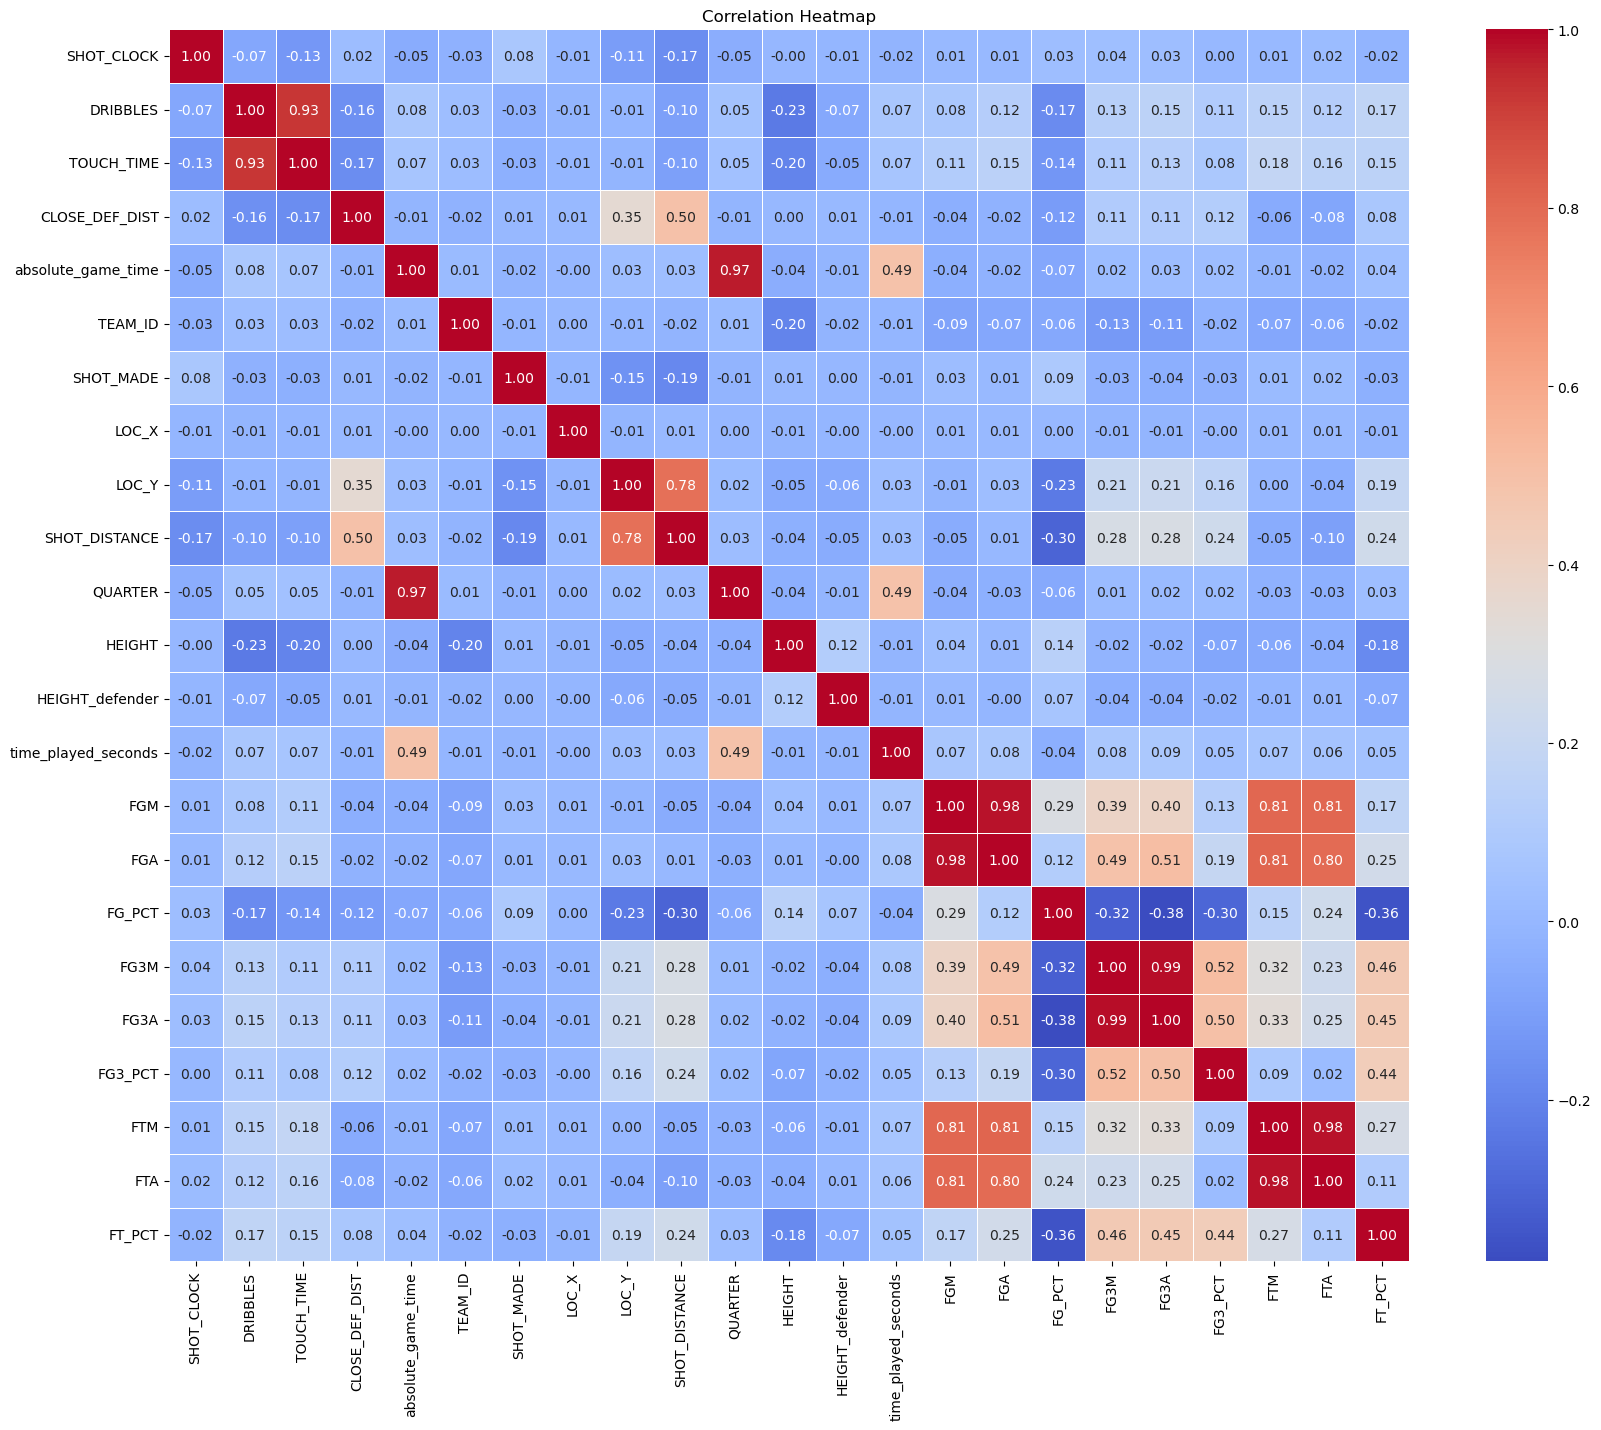

In [872]:
visualize_heatmap(for_pred, numerical_cols)

Example of strong positive correlation from heatmap:  
    FGM (Field Goals Made) and FGA (Field Goals Attempted) - 0.99.  
  This makes sense because the number of shots made is directly linked to the number of shots attempted.

Example of strong negative correlation from heatmap:  
 FG_PCT (Field Goal Percentage) and FGA (Field Goal Attempts) - (-0.36)  
  This can suggests that as a player takes more shots, their shooting percentage tends to decrease.   
    This could indicate fatigue effects or defensive adjustments.


Visualization :

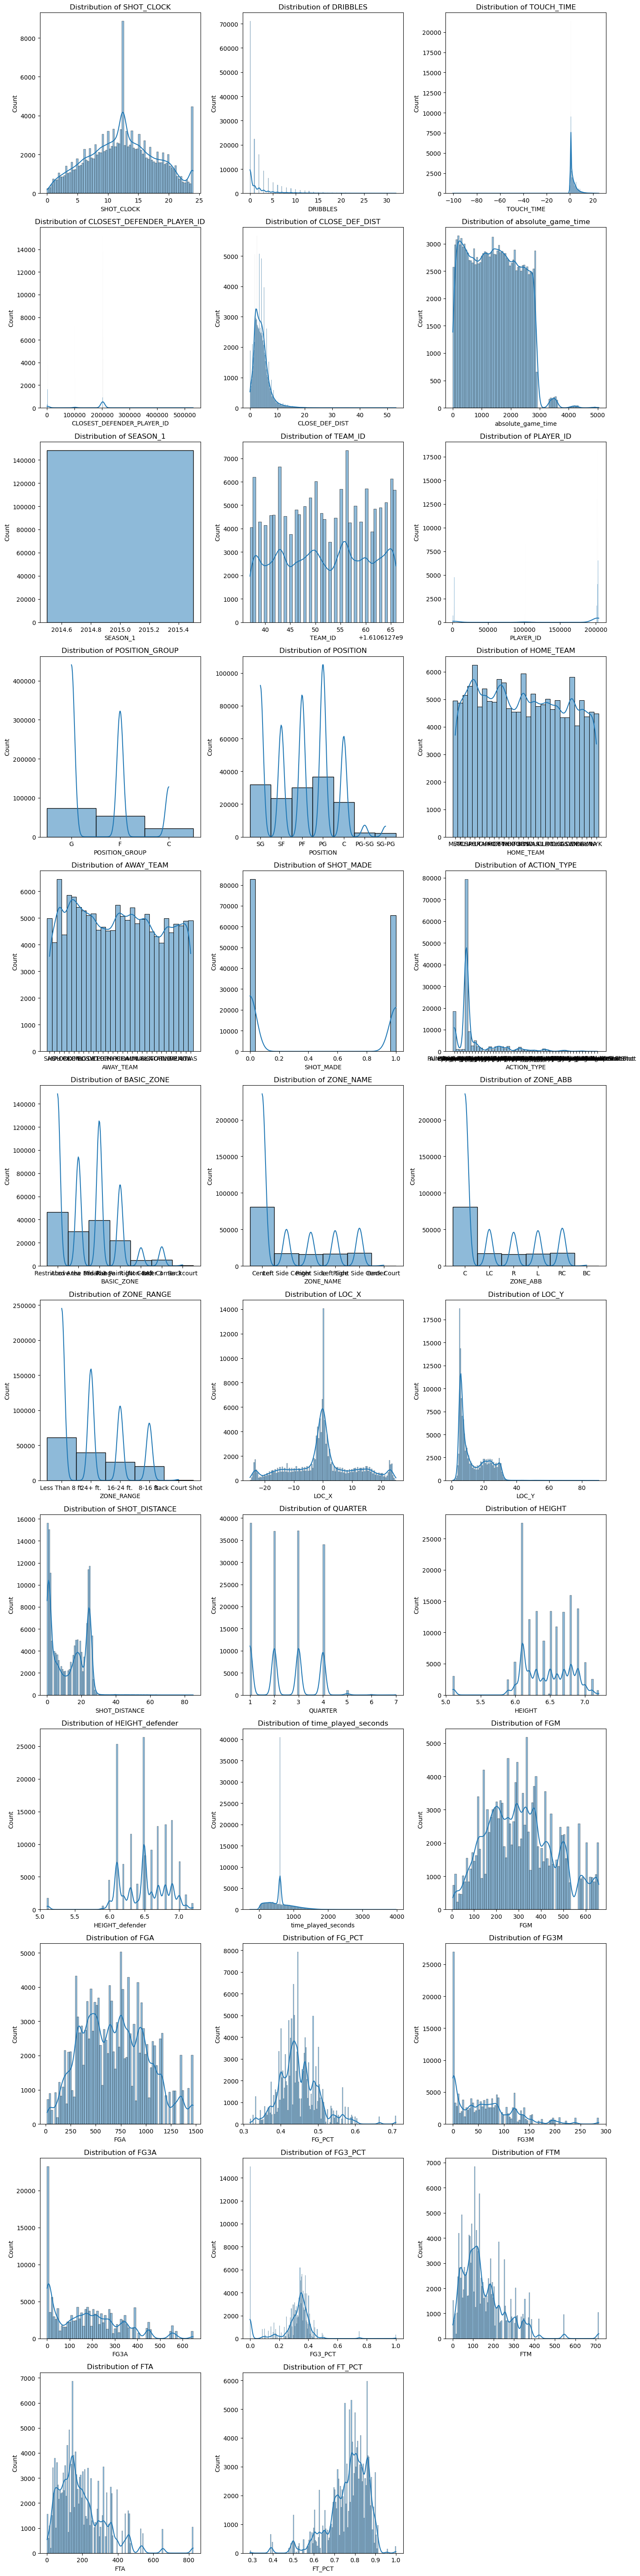

In [877]:
visualize_distributions(for_pred, numerical_cols=for_pred.columns)

Reloads the du module and calls du.missing_values_summary(for_pred) to generate a summary of missing values in for_pred : 

In [878]:
importlib.reload(du)
missing_summary = du.missing_values_summary(for_pred)
print(missing_summary)

Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


check for duplicate rows :

In [882]:
# check for duplicate rows in the data for prediction
duplicate_rows = for_pred[for_pred.duplicated()]

# display the duplicate rows
print(duplicate_rows)


        SHOT_CLOCK  DRIBBLES  TOUCH_TIME  CLOSEST_DEFENDER_PLAYER_ID  \
2194          24.0         0         0.0                      101187   
8032          24.0         0         0.0                        2561   
23571         22.5         0         0.0                      201959   
72128         10.0         0         0.0                      202694   
95863         24.0         0         0.0                      203096   
113995         8.5         0         1.0                        2210   
114335        21.5         2         2.5                      201572   
120832        11.6         3         5.7                      203475   
120833        11.6         3         5.7                      203475   
120834        11.6         3         5.7                      203475   
123718        12.0         2         3.3                        2747   
125500        17.0         0         0.9                        2747   
125595        13.5         3         5.7                        

Remove duplicate rows from for_pred : 

In [884]:
for_pred = for_pred.drop_duplicates().reset_index(drop=True)

Check for canstant columns :

In [886]:
importlib.reload(du)
constant_columns = du.find_constant_columns(for_pred)
print("Columns with constant values:", constant_columns)

Found 1 constant columns
Columns with constant values: ['SEASON_1']


Drop the constant columns :

In [888]:
for_pred = for_pred.drop(columns=constant_columns)

In [890]:
for_pred.head()

,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,absolute_game_time,TEAM_ID,PLAYER_ID,POSITION_GROUP,POSITION,...,time_played_seconds,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT
0,22.0,2,1.8,202709,2.3,3.0,1.610613e+09,2754,G,SG,...,601.059167,225,455,0.495,10,29,0.345,79,126,0.627
1,22.5,2,2.5,201960,3.5,4.0,1.610613e+09,2772,F,SF,...,601.059167,366,910,0.402,194,555,0.350,122,143,0.853
2,21.8,3,3.2,201565,5.3,4.0,1.610613e+09,202693,F,PF,...,601.059167,512,1100,0.465,57,179,0.318,177,232,0.763
3,21.1,0,1.3,203095,3.4,4.0,1.610613e+09,203463,G,SG,...,601.059167,363,831,0.437,140,391,0.358,130,160,0.813
4,20.6,0,0.0,201586,4.0,4.0,1.610613e+09,202693,F,PF,...,601.059167,512,1100,0.465,57,179,0.318,177,232,0.763


In [892]:
for_pred.columns

Index(['SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER_PLAYER_ID',
       'CLOSE_DEF_DIST', 'absolute_game_time', 'TEAM_ID', 'PLAYER_ID',
       'POSITION_GROUP', 'POSITION', 'HOME_TEAM', 'AWAY_TEAM', 'SHOT_MADE',
       'ACTION_TYPE', 'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE',
       'LOC_X', 'LOC_Y', 'SHOT_DISTANCE', 'QUARTER', 'HEIGHT',
       'HEIGHT_defender', 'time_played_seconds', 'FGM', 'FGA', 'FG_PCT',
       'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT'],
      dtype='object')

In [894]:
for_pred

,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,absolute_game_time,TEAM_ID,PLAYER_ID,POSITION_GROUP,POSITION,...,time_played_seconds,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT
0,22.000000,2,1.8,202709,2.3,3.0,1.610613e+09,2754,G,SG,...,601.059167,225,455,0.495,10,29,0.345,79,126,0.627
1,22.500000,2,2.5,201960,3.5,4.0,1.610613e+09,2772,F,SF,...,601.059167,366,910,0.402,194,555,0.350,122,143,0.853
2,21.800000,3,3.2,201565,5.3,4.0,1.610613e+09,202693,F,PF,...,601.059167,512,1100,0.465,57,179,0.318,177,232,0.763
3,21.100000,0,1.3,203095,3.4,4.0,1.610613e+09,203463,G,SG,...,601.059167,363,831,0.437,140,391,0.358,130,160,0.813
4,20.600000,0,0.0,201586,4.0,4.0,1.610613e+09,202693,F,PF,...,601.059167,512,1100,0.465,57,179,0.318,177,232,0.763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148201,6.300000,17,17.7,1495,5.0,5017.0,1.610613e+09,201144,G,PG,...,3039.000000,393,882,0.446,107,277,0.386,214,249,0.859
148202,0.700000,1,2.1,1495,9.8,5023.0,1.610613e+09,201584,G,SG,...,3970.000000,288,643,0.448,90,224,0.402,111,129,0.860
148203,12.453344,0,0.8,203507,3.9,5030.0,1.610613e+09,2207,G,SG,...,3657.000000,446,1025,0.435,121,337,0.359,141,176,0.801
148204,12.453344,9,6.4,201188,5.1,5035.0,1.610613e+09,1938,G,SG,...,1090.000000,251,589,0.426,89,258,0.345,147,204,0.721


## Prepare the data for machine learning models:

Defind SHOT_MADE as a taget column :

In [897]:
target_column = 'SHOT_MADE'

Check the distribution of SHOT_MADE :

<Axes: ylabel='count'>

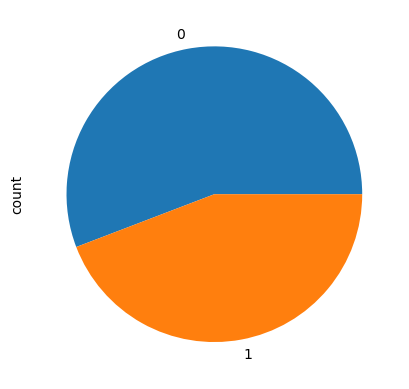

In [899]:
for_pred['SHOT_MADE'].value_counts().plot(kind='pie')

Separates the features (X) and the target variable (y) for model training : 

In [901]:
X = for_pred.drop(target_column, axis=1)
y = for_pred[target_column]

In [903]:
y

0         0
1         1
2         1
3         1
4         1
         ..
148201    0
148202    0
148203    0
148204    0
148205    0
Name: SHOT_MADE, Length: 148206, dtype: int64

In [905]:
X.head()

,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,absolute_game_time,TEAM_ID,PLAYER_ID,POSITION_GROUP,POSITION,...,time_played_seconds,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT
0,22.0,2,1.8,202709,2.3,3.0,1.610613e+09,2754,G,SG,...,601.059167,225,455,0.495,10,29,0.345,79,126,0.627
1,22.5,2,2.5,201960,3.5,4.0,1.610613e+09,2772,F,SF,...,601.059167,366,910,0.402,194,555,0.350,122,143,0.853
2,21.8,3,3.2,201565,5.3,4.0,1.610613e+09,202693,F,PF,...,601.059167,512,1100,0.465,57,179,0.318,177,232,0.763
3,21.1,0,1.3,203095,3.4,4.0,1.610613e+09,203463,G,SG,...,601.059167,363,831,0.437,140,391,0.358,130,160,0.813
4,20.6,0,0.0,201586,4.0,4.0,1.610613e+09,202693,F,PF,...,601.059167,512,1100,0.465,57,179,0.318,177,232,0.763


In [907]:
X.columns

Index(['SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER_PLAYER_ID',
       'CLOSE_DEF_DIST', 'absolute_game_time', 'TEAM_ID', 'PLAYER_ID',
       'POSITION_GROUP', 'POSITION', 'HOME_TEAM', 'AWAY_TEAM', 'ACTION_TYPE',
       'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE', 'LOC_X', 'LOC_Y',
       'SHOT_DISTANCE', 'QUARTER', 'HEIGHT', 'HEIGHT_defender',
       'time_played_seconds', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A',
       'FG3_PCT', 'FTM', 'FTA', 'FT_PCT'],
      dtype='object')

Separate numerical and categorical features in the dataset:

In [909]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

Ensuring that all features are classified correctly before further preprocessing, check that all the columns are numerical or categorical :

In [911]:
all_columns = set(X.columns)
numerical_and_categorical = set(numerical_cols).union(set(categorical_cols))
other_columns = all_columns - numerical_and_categorical

print("Columns that are not in numerical or categorical:")
print(other_columns)

Columns that are not in numerical or categorical:
set()


Handle missing values:  
  fills missing values in numerical columns using the mean value of each column :

In [913]:
num_imputer = SimpleImputer(strategy='mean')
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])

Fills missing values in categorical columns using the most frequent (mode) value of each column :

In [915]:
# Categorical imputer for missing values
cat_imputer = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

Encode categorical features into numerical values using LabelEncoder, which converts each unique category into an integer : 

In [917]:
encoders = {}
for col in categorical_cols:
    encoders[col] = LabelEncoder()
    X[col] = encoders[col].fit_transform(X[col])

Standardizes numerical features by scaling them to have a mean of 0 and a standard deviation of 1 using StandardScaler :

In [919]:
# Scale numerical features
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols]) # zero mean and unit variance for the numerical columns

In [921]:
X.head()

,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,absolute_game_time,TEAM_ID,PLAYER_ID,POSITION_GROUP,POSITION,...,time_played_seconds,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT
0,1.698271,-0.038732,-0.341960,0.552940,-0.658734,-1.678407,1.289308,-1.993054,2,5,...,0.002708,-0.562245,-0.715275,0.866176,-0.952135,-1.026439,0.330812,-0.663418,-0.516568,-1.521742
1,1.787231,-0.038732,-0.112760,0.543423,-0.221244,-1.677231,-0.778393,-1.992825,1,4,...,0.002708,0.360042,0.682676,-0.890106,2.302821,2.556816,0.370084,-0.269539,-0.388781,0.872956
2,1.662688,0.239817,0.116440,0.538405,0.434992,-1.677231,0.485202,0.555559,1,1,...,0.002708,1.315034,1.266436,0.299634,-0.120706,-0.004598,0.118739,0.234258,0.280222,-0.080685
3,1.538144,-0.595831,-0.505674,0.557845,-0.257701,-1.677231,0.714946,0.565374,2,5,...,0.002708,0.340419,0.439955,-0.229139,1.347562,1.439604,0.432921,-0.196260,-0.260994,0.449116
4,1.449184,-0.595831,-0.931332,0.538671,-0.038956,-1.677231,0.485202,0.555559,1,1,...,0.002708,1.315034,1.266436,0.299634,-0.120706,-0.004598,0.118739,0.234258,0.280222,-0.080685


Split the dataset into training, validation, and test sets, ensuring the model is properly trained and evaluated: 

In [923]:
X_train, X_val, X_test, y_train, y_val, y_test = du.split_dataset(X, y, test_size=0.1, validation_size=0.2, random_state=2312)

In [925]:
X_train.columns

Index(['SHOT_CLOCK', 'DRIBBLES', 'TOUCH_TIME', 'CLOSEST_DEFENDER_PLAYER_ID',
       'CLOSE_DEF_DIST', 'absolute_game_time', 'TEAM_ID', 'PLAYER_ID',
       'POSITION_GROUP', 'POSITION', 'HOME_TEAM', 'AWAY_TEAM', 'ACTION_TYPE',
       'BASIC_ZONE', 'ZONE_NAME', 'ZONE_ABB', 'ZONE_RANGE', 'LOC_X', 'LOC_Y',
       'SHOT_DISTANCE', 'QUARTER', 'HEIGHT', 'HEIGHT_defender',
       'time_played_seconds', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A',
       'FG3_PCT', 'FTM', 'FTA', 'FT_PCT'],
      dtype='object')

Remove rows with missing values from X_train:

In [927]:
X_train.dropna()

,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,absolute_game_time,TEAM_ID,PLAYER_ID,POSITION_GROUP,POSITION,...,time_played_seconds,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT
124740,1.484768,0.518367,0.443869,-1.992167,-1.278512,1.160592,-0.548649,0.535967,2,5,...,1.120757,-0.895838,-0.650754,-1.569957,0.339234,0.308767,0.519321,-0.177940,-0.351196,1.286200
102827,-0.009757,-0.595831,-0.702132,0.548061,0.143332,0.629015,-0.778393,-2.004055,2,5,...,0.402892,-0.804264,-0.742927,-0.512411,1.099903,0.976369,0.684266,-1.029816,-1.102884,0.449116
93034,1.769439,-0.317282,-0.145503,0.538557,-1.132682,0.402036,-1.008138,0.551684,0,0,...,1.413426,0.019908,-0.374236,1.999261,-1.093655,-1.183121,0.236557,0.032739,0.159952,-0.557505
100347,0.630753,-0.595831,-0.669389,0.533297,2.148495,0.570212,0.714946,0.565374,2,5,...,-1.179173,0.340419,0.439955,-0.229139,1.347562,1.439604,0.432921,-0.196260,-0.260994,0.449116
113846,0.986593,1.075466,1.000498,0.533284,0.544364,0.888923,1.633925,0.551697,2,5,...,0.168205,-1.098611,-0.890403,-1.702150,-0.439125,-0.317962,-0.077625,-0.580978,-0.696973,0.978916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117821,-1.842330,-0.038732,-0.145503,-1.991786,-0.585819,0.988888,0.600074,-1.995667,0,0,...,-0.292885,-0.182864,-0.426467,1.243871,-1.129035,-1.223995,-2.379008,-0.727537,-0.696973,-0.684657
120281,-0.739228,-0.595831,-0.865846,0.557629,-0.367074,1.050042,-1.697372,0.535801,0,0,...,2.307996,1.360822,0.851659,1.678220,-0.934445,-0.978753,0.024484,-0.406939,-0.403814,-0.123069
113931,-0.383389,-0.595831,-0.276474,0.533132,-0.549361,0.891275,0.714946,0.536158,1,1,...,-0.712560,-0.791182,-0.979503,1.243871,-1.129035,-1.223995,-2.379008,-0.260379,-0.336163,0.523288
13622,0.346082,-0.595831,-0.505674,0.552635,0.033959,-1.384393,-1.467627,0.551684,0,0,...,0.002708,0.019908,-0.374236,1.999261,-1.093655,-1.183121,0.236557,0.032739,0.159952,-0.557505


Ensures that the target variables are stored as integers :

In [929]:
y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

## Model Training and Evaluation: Comparing Machine Learning Algorithms

### Logistic regression using L2 and L1 regularizations:  
 L1 and L2 regularization are techniques used in logistic regression to prevent overfitting by adding a penalty term to the loss function.

L1 Regularization (Lasso) adds the absolute values of the coefficients (|β|) as a penalty. This encourages sparsity, meaning some coefficients become exactly zero, effectively performing feature selection. L1 is useful when we suspect that only a few features are truly important.

L2 Regularization (Ridge) adds the squared values of the coefficients (β²) as a penalty. This discourages large coefficients but does not force them to zero, meaning all features still contribute to the model. L2 is useful when all features contain some predictive power but need to be scaled down to avoid overfitting.

Key Differences:  
    L1 results in sparse models (some features eliminated), while L2 retains all features.  
       L1 is better for feature selection, while L2 is better for handling multicollinearity.  
                    L2 generally leads to smoother, more stable models, whereas L1 can produce sharper feature selection. 

In [932]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# Initialize the logistic regression model with L2 regularization
logistic_model_l2 = LogisticRegression(max_iter=1000, random_state=2312)
logistic_model_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=2312)

# Fit the model on the training data
logistic_model_l2.fit(X_train, y_train)
logistic_model_l1.fit(X_train, y_train)

LogisticRegression(max_iter=1000, penalty='l1', random_state=2312,
                   solver='liblinear')

Accuracy scores of two logistic regression models on the training set:

In [933]:
print(logistic_model_l2.score(X_train, y_train),logistic_model_l1.score(X_train, y_train))

0.6191194662068449 0.6189320388349514


Defind val and test variables :

In [934]:
y_val_pred_l2 = logistic_model_l2.predict(X_val)
y_val_pred_l1 = logistic_model_l1.predict(X_val)

In [938]:
y_test_pred_l2 = logistic_model_l2.predict(X_test)
y_test_pred_l1 = logistic_model_l1.predict(X_test)

In [940]:
accuracy_score(y_val, y_val_pred_l2), accuracy_score(y_val, y_val_pred_l1)

(0.6182854144019193, 0.6181729579787832)

In [942]:
accuracy_score(y_test, y_test_pred_l2), accuracy_score(y_test, y_test_pred_l1)

(0.6152756224276364, 0.6157479252412118)

Accuracy: 0.6183
Precision: 0.5920
Recall: 0.4340
F1 Score: 0.5008
ROC AUC: 0.5989


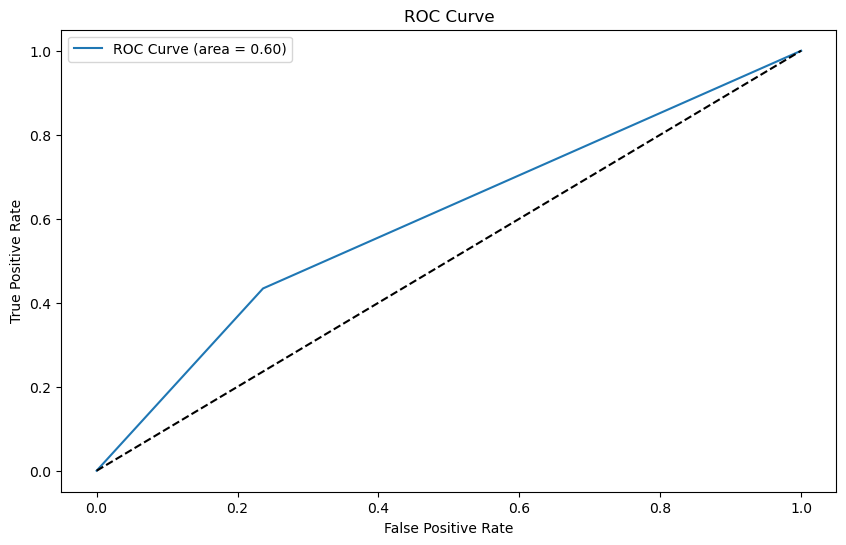

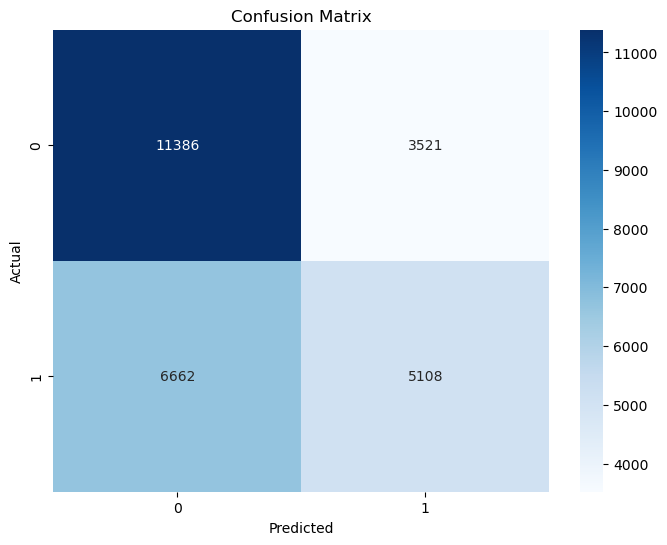

In [944]:
# Calculate metrics for l2
accuracy = accuracy_score(y_val, y_val_pred_l2)
precision = precision_score(y_val, y_val_pred_l2)
recall = recall_score(y_val, y_val_pred_l2)
f1 = f1_score(y_val, y_val_pred_l2)
roc_auc = roc_auc_score(y_val, y_val_pred_l2)

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_l2)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Plot confusion matrix
conf_matrix = confusion_matrix(y_val, y_val_pred_l2)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

conclusions l2 Matrix on the validation set :

False Negatives (Missed shots classified as missed correctly) are relatively high.   
    False Positives (Missed shots wrongly classified as made) seem frequent.  
        This can indicate that the model is likely too conservative in predicting successful shots and often misclassifies them as misses.



Accuracy: 0.6182
Precision: 0.5917
Recall: 0.4343
F1 Score: 0.5009
ROC AUC: 0.5988


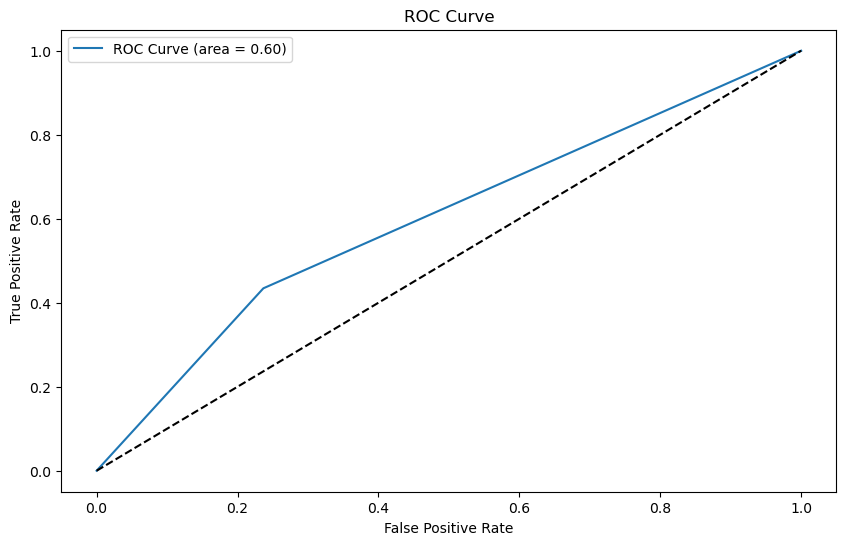

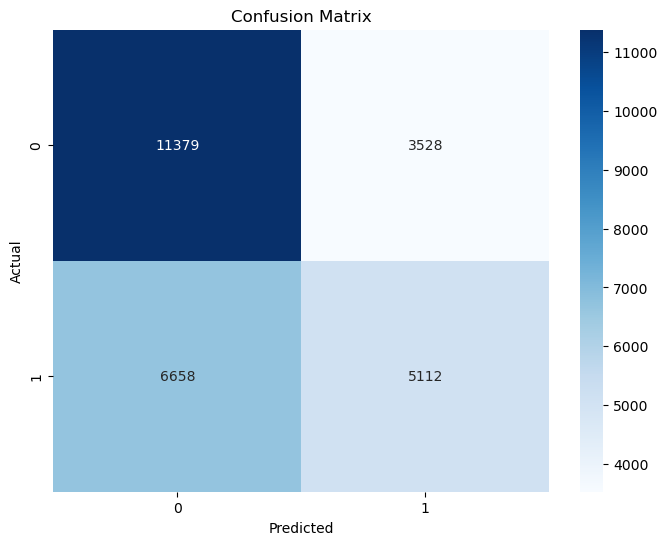

In [947]:
# Calculate metrics for l1
accuracy = accuracy_score(y_val, y_val_pred_l1)
precision = precision_score(y_val, y_val_pred_l1)
recall = recall_score(y_val, y_val_pred_l1)
f1 = f1_score(y_val, y_val_pred_l1)
roc_auc = roc_auc_score(y_val, y_val_pred_l1)

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_val, y_val_pred_l1)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Plot confusion matrix
conf_matrix = confusion_matrix(y_val, y_val_pred_l1)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

l1 matrix on the validation set get the same results as l2 .

In [950]:
y_test_pred_l2 = logistic_model_l2.predict(X_test)
y_test_pred_l1 = logistic_model_l1.predict(X_test)

In [952]:
y_test_proba_l2 = logistic_model_l2.predict_proba(X_test)[:, 1]
y_test_proba_l1 = logistic_model_l1.predict_proba(X_test)[:, 1]

The difference between predict() and predict_proba() is that predict() returns class labels (0 or 1), while predict_proba() returns probability scores for each class ,in this case: returns the predicted probability that each shot was made (1) .

In [955]:
accuracy_l2 = accuracy_score(y_test, y_test_pred_l2)
precision_l2 = precision_score(y_test, y_test_pred_l2)
recall_l2 = recall_score(y_test, y_test_pred_l2)
f1_l2 = f1_score(y_test, y_test_pred_l2)
roc_auc_l2 = roc_auc_score(y_test, y_test_proba_l2)

In [957]:
print("\n📊 **Logistic Regression - L2 Regularization** 📊")
print(f"Accuracy: {accuracy_l2:.4f}")
print(f"Precision: {precision_l2:.4f}")
print(f"Recall: {recall_l2:.4f}")
print(f"F1 Score: {f1_l2:.4f}")
print(f"ROC AUC: {roc_auc_l2:.4f}")


📊 **Logistic Regression - L2 Regularization** 📊
Accuracy: 0.6153
Precision: 0.5919
Recall: 0.4435
F1 Score: 0.5071
ROC AUC: 0.6306


In [959]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred_l2))

              precision    recall  f1-score   support

           0       0.63      0.75      0.68      8208
           1       0.59      0.44      0.51      6613

    accuracy                           0.62     14821
   macro avg       0.61      0.60      0.60     14821
weighted avg       0.61      0.62      0.61     14821



conclusions l2 Matrix on the test set :  
    the model is better at detecting missed shots than successful ones.   
      Since recall is high (0.75), the model is less likely to mistakenly classify a missed shot as made.

In [962]:
fpr_l2, tpr_l2, _ = roc_curve(y_test, y_test_proba_l2)

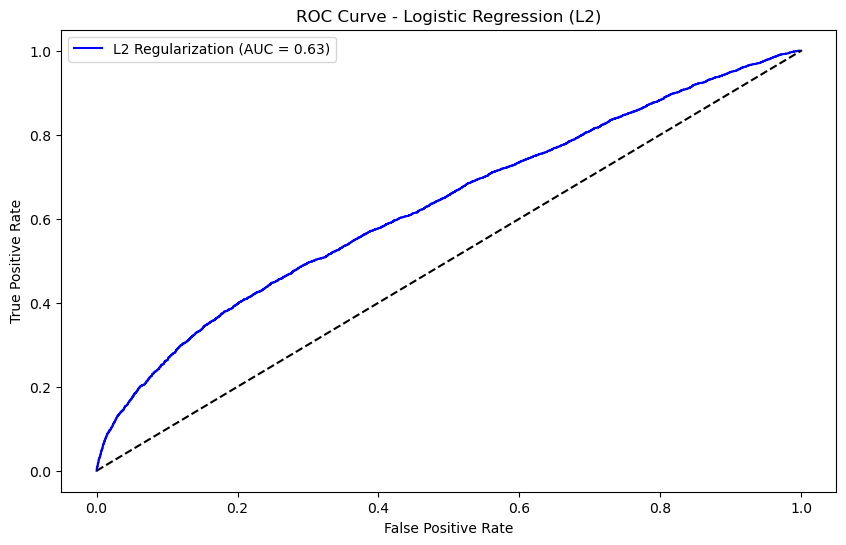

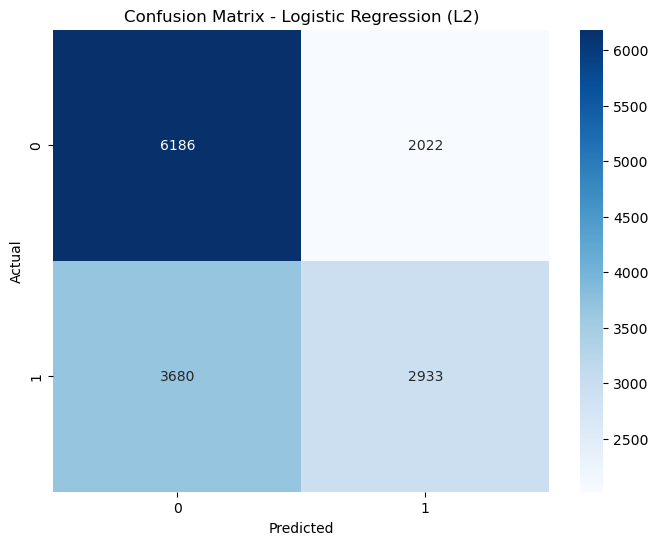

In [964]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_l2, tpr_l2, label=f'L2 Regularization (AUC = {roc_auc_l2:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--')  # קו אקראי
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (L2)')
plt.legend(loc='best')
plt.show()


conf_matrix_l2 = confusion_matrix(y_test, y_test_pred_l2)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_l2, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (L2)')
plt.show()

In [966]:
accuracy_l1 = accuracy_score(y_test, y_test_pred_l1)
precision_l1 = precision_score(y_test, y_test_pred_l1)
recall_l1 = recall_score(y_test, y_test_pred_l1)
f1_l1 = f1_score(y_test, y_test_pred_l1)
roc_auc_l1 = roc_auc_score(y_test, y_test_proba_l1)

In [968]:
print("\n📊 **Logistic Regression - L1 Regularization** 📊")
print(f"Accuracy: {accuracy_l1:.4f}")
print(f"Precision: {precision_l1:.4f}")
print(f"Recall: {recall_l1:.4f}")
print(f"F1 Score: {f1_l1:.4f}")
print(f"ROC AUC: {roc_auc_l1:.4f}")


📊 **Logistic Regression - L1 Regularization** 📊
Accuracy: 0.6157
Precision: 0.5926
Recall: 0.4441
F1 Score: 0.5077
ROC AUC: 0.6307


In [970]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_test_pred_l1))

              precision    recall  f1-score   support

           0       0.63      0.75      0.68      8208
           1       0.59      0.44      0.51      6613

    accuracy                           0.62     14821
   macro avg       0.61      0.60      0.60     14821
weighted avg       0.61      0.62      0.61     14821



conclusions l1 Matrix on the test set :  
l1 matrix on the test set get the same results as l2 .

In [973]:
fpr_l1, tpr_l1, _ = roc_curve(y_test, y_test_proba_l1)

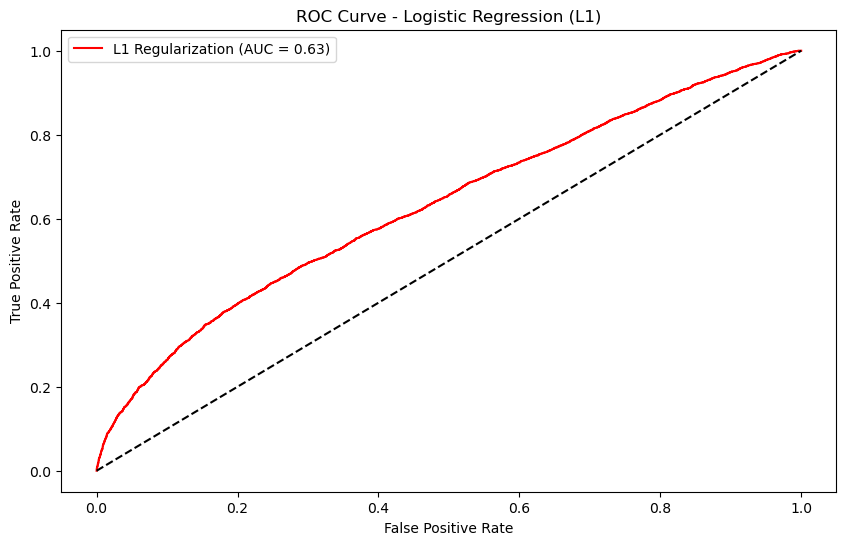

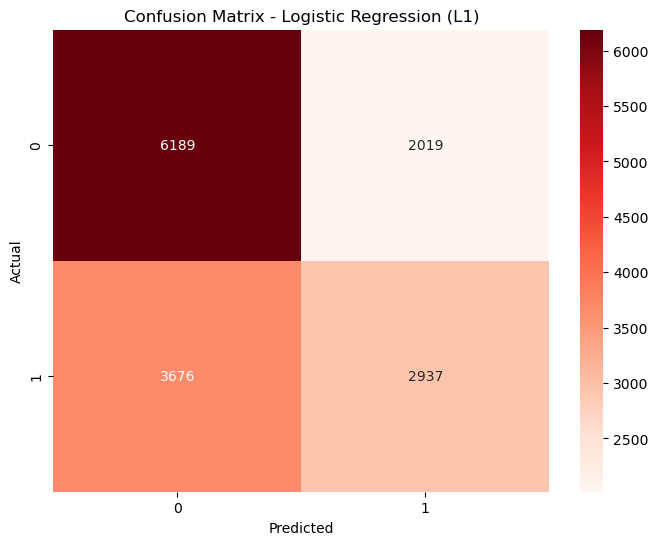

In [975]:
plt.figure(figsize=(10, 6))
plt.plot(fpr_l1, tpr_l1, label=f'L1 Regularization (AUC = {roc_auc_l1:.2f})', color='red')
plt.plot([0, 1], [0, 1], 'k--')  # קו אקראי
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression (L1)')
plt.legend(loc='best')
plt.show()


conf_matrix_l1 = confusion_matrix(y_test, y_test_pred_l1)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_l1, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression (L1)')
plt.show()

Conclusions Logistic regression :  
The accuracy (62%) is only slightly better than random guessing (50%).  
The ROC AUC (0.60) suggests the models struggle to distinguish between made and missed shots effectively. 
Logistic regression provides a baseline model, but it struggles with complex interactions in shot prediction.

## SVM: 
SVM is a supervised learning algorithm used for classification and regression tasks. It works by finding the optimal hyperplane that best separates different classes in the feature space. In cases where the data is not linearly separable, SVM can use kernel functions  to transform the data into a higher-dimensional space where it becomes more separable.

In [979]:
# check the class balance. if balanced, we don't need to use class_weight='balanced'
y.value_counts()

SHOT_MADE
0    82717
1    65489
Name: count, dtype: int64

In [981]:
from sklearn import svm

# Initialize the SVM model
svm_model = svm.SVC(random_state=2312, cache_size=800)

In [983]:
svm_model.fit(X_train, y_train)

SVC(cache_size=800, random_state=2312)

In [984]:
#svm_model.score(X_train, y_train)

In [985]:
svm_val_pred = svm_model.predict(X_val)

In [986]:
svm_val_pred

array([0, 1, 1, ..., 0, 1, 0])

In [987]:
accuracy = accuracy_score(y_val, svm_val_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6247


Accuracy: 0.6247
Precision: 0.6676
Recall: 0.2974
F1 Score: 0.4115
ROC AUC: 0.5902


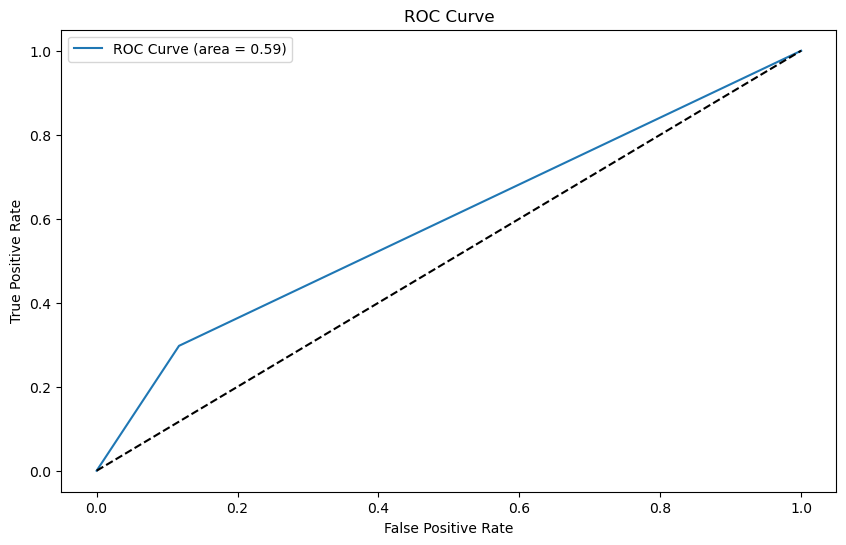

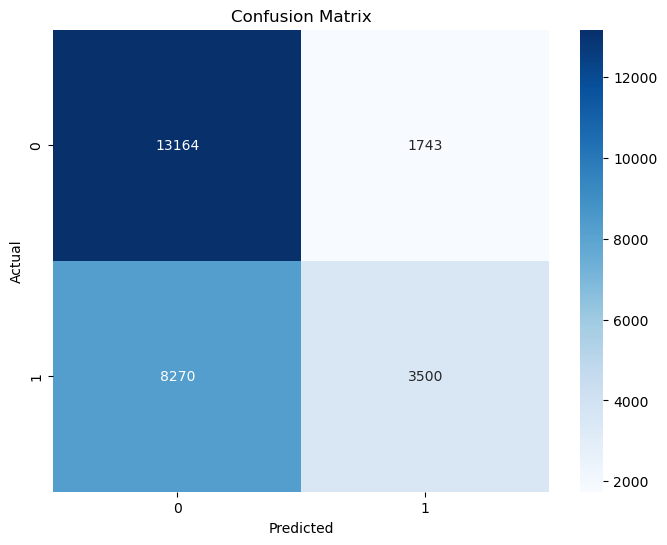

In [988]:
accuracy = accuracy_score(y_val, svm_val_pred)
precision = precision_score(y_val, svm_val_pred)
recall = recall_score(y_val, svm_val_pred)
f1 = f1_score(y_val, svm_val_pred)
roc_auc = roc_auc_score(y_val, svm_val_pred)

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_val, svm_val_pred)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Plot confusion matrix
conf_matrix = confusion_matrix(y_val, svm_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [989]:
svm_test_pred = svm_model.predict(X_test)

In [990]:
accuracy = accuracy_score(y_test, svm_test_pred)
precision = precision_score(y_test, svm_test_pred)
recall = recall_score(y_test, svm_test_pred)
f1 = f1_score(y_test, svm_test_pred)
roc_auc = roc_auc_score(y_test, svm_test_pred)

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Accuracy: 0.6213
Precision: 0.6651
Recall: 0.3046
F1 Score: 0.4178
ROC AUC: 0.5905


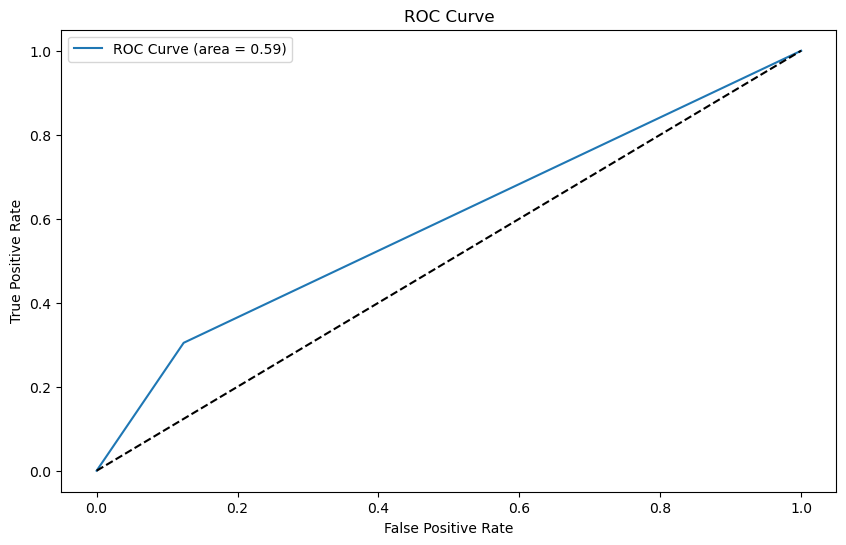

In [991]:
#Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, svm_test_pred)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

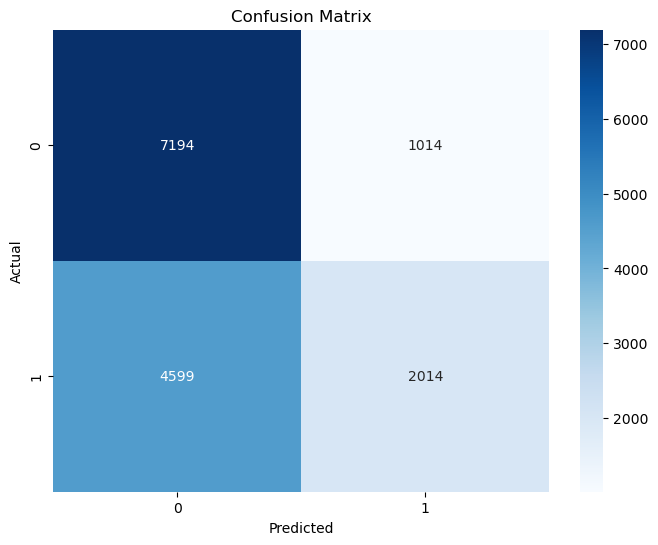

In [992]:

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, svm_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Conclusions SVM : 


In [994]:
# ---> run for hours..
##from sklearn.model_selection import GridSearchCV

# Define the parameter grid
##param_grid = [
  ##{'C': [1, 10, 100, 1000], 'kernel': ['linear']},
  ##{'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001], 'kernel': ['rbf']},
 ##]

# Initialize the GridSearchCV object
##grid_search = GridSearchCV(svm_model, param_grid, refit=True, verbose=2, cv=5, n_jobs=-1)

# Fit the grid search to the data
##grid_search.fit(X_train, y_train)

In [995]:
#grid_search_results = pd.DataFrame(grid_search.cv_results_)

In [996]:
 #Print the best parameters and best score
##  print(f"Best Parameters: {grid_search.best_params_}")
##  print(f"Best Score: {grid_search.best_score_}")

# Update the svm_model with the best parameters
##  best_svm_model = grid_search.best_estimator_

In [997]:
##best_svm_model = grid_search.best_estimator_
##best_svm_model.fit(X_train, y_train)


In [998]:
##svm_grid_test_pred = best_svm_model.predict(X_test)

##  RANDOM FOREST:   
  Random Forest is an ensemble learning algorithm that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting. Each tree is trained on a random subset of the data using a technique called bagging , which helps the model generalize well to new data. The final prediction is determined by majority voting (for classification) or averaging (for regression).

In [1000]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(random_state=2312, n_estimators=200)

In [1001]:
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=2312)

In [1002]:
val_rf_pred = random_forest_model.predict(X_val)

In [1003]:
accuracy = accuracy_score(y_val, val_rf_pred)
precision = precision_score(y_val, val_rf_pred)
recall = recall_score(y_val, val_rf_pred)
f1 = f1_score(y_val, val_rf_pred)
roc_auc = roc_auc_score(y_val, val_rf_pred)

# Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(classification_report(y_val, val_rf_pred))

Accuracy: 0.7115
Precision: 0.7425
Recall: 0.5297
F1 Score: 0.6183
ROC AUC: 0.6924
              precision    recall  f1-score   support

           0       0.70      0.85      0.77     14907
           1       0.74      0.53      0.62     11770

    accuracy                           0.71     26677
   macro avg       0.72      0.69      0.69     26677
weighted avg       0.72      0.71      0.70     26677



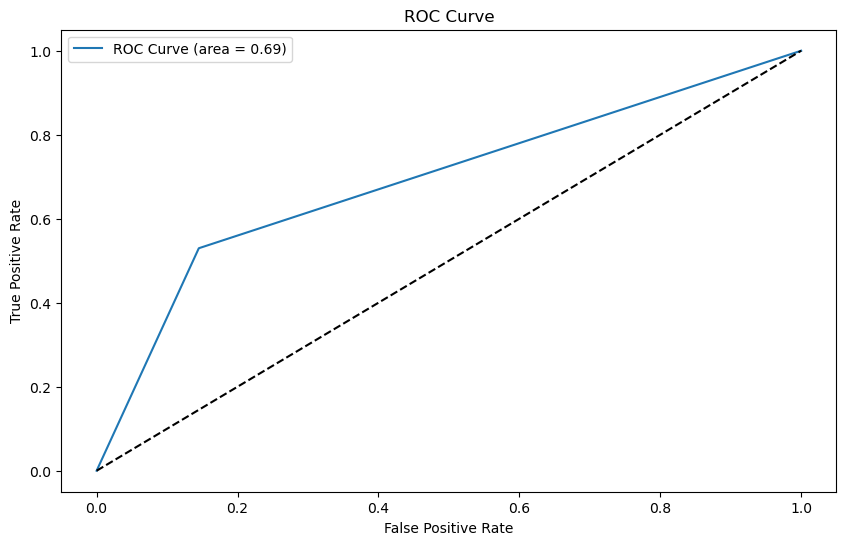

In [1004]:
#Plot ROC curve
fpr, tpr, _ = roc_curve(y_val, val_rf_pred)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

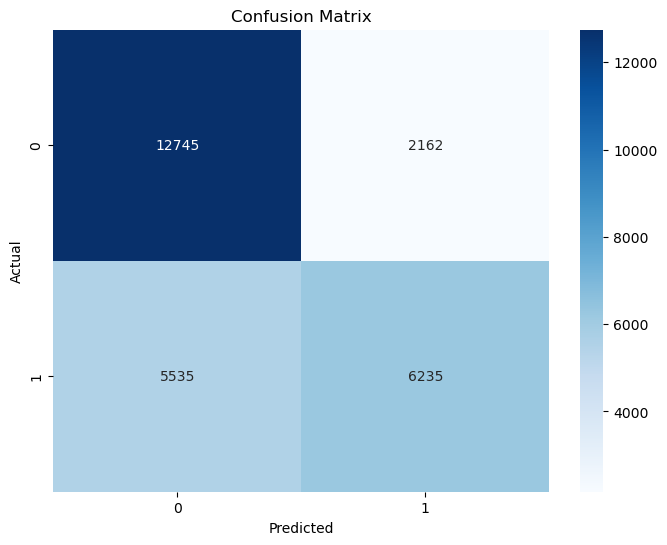

In [1005]:

# Plot confusion matrix
conf_matrix = confusion_matrix(y_val, val_rf_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

/var/folders/fh/lr2n8w4x2hlcn416x09v4d6m0000gn/T/ipykernel_13087/785036201.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')


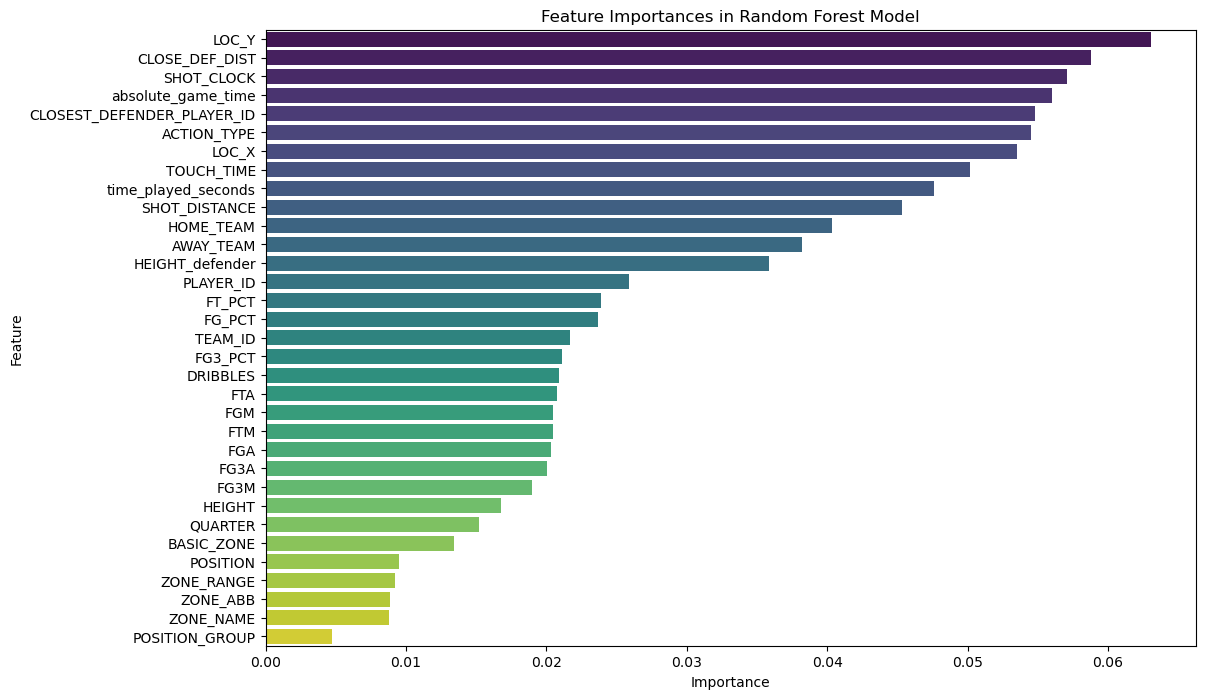

In [1006]:
# Get feature importances from the random forest model
importances = random_forest_model.feature_importances_

# Create a DataFrame for better visualization
feature_importances = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})

# Sort the DataFrame by importance
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('Feature Importances in Random Forest Model')
plt.show()

In [1007]:
y_test_pred_rf = random_forest_model.predict(X_test)

In [1008]:
accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
precision_rf = precision_score(y_test, y_test_pred_rf)
recall_rf = recall_score(y_test, y_test_pred_rf)
f1_rf = f1_score(y_test, y_test_pred_rf)
roc_auc_rf = roc_auc_score(y_test, random_forest_model.predict_proba(X_test)[:, 1])

In [1009]:
print("\n📊 **Random Forest - Test Metrics** 📊")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")
print(f"ROC AUC: {roc_auc_rf:.4f}")


📊 **Random Forest - Test Metrics** 📊
Accuracy: 0.7104
Precision: 0.7426
Recall: 0.5371
F1 Score: 0.6234
ROC AUC: 0.7751


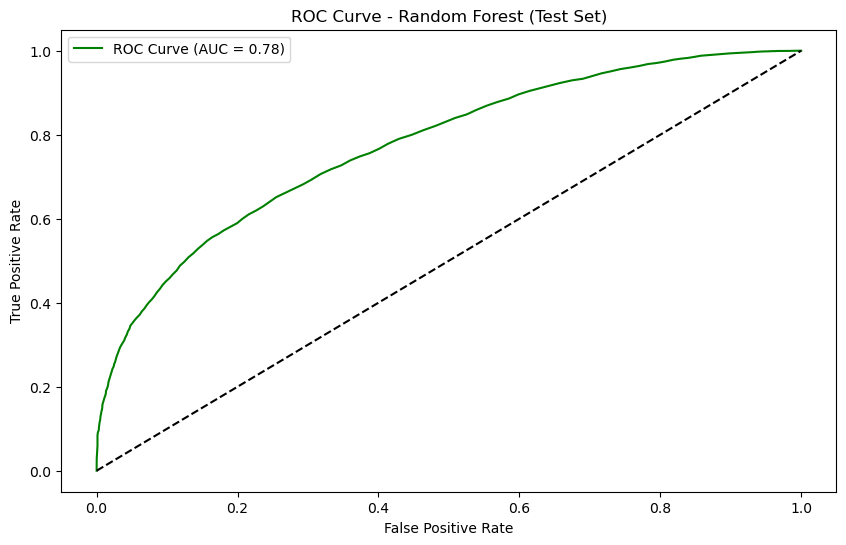

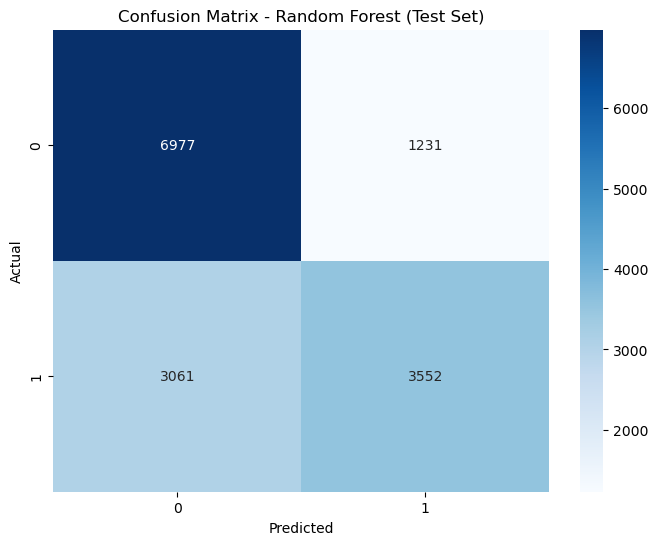

In [1010]:
#ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, random_forest_model.predict_proba(X_test)[:, 1])
plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, label=f'ROC Curve (AUC = {roc_auc_rf:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (Test Set)')
plt.legend(loc='best')
plt.show()

#Confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (Test Set)')
plt.show()

Conclusions Random Forest : 


## NAIVE BAYES:
Naïve Bayes is a probabilistic classification algorithm based on Bayes’ Theorem, which calculates the probability of an event occurring given prior knowledge of related factors. It assumes that all features are independent (hence "naïve"), which simplifies computations and makes the model highly efficient.

In [1013]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

In [1014]:
#Naive bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [1015]:
y_pred_nb = nb_model.predict(X_val)

In [1016]:
accuracy = accuracy_score(y_val, y_pred_nb)
precision = precision_score(y_val, y_pred_nb)
recall = recall_score(y_val, y_pred_nb)
f1 = f1_score(y_val, y_pred_nb)
roc_auc = roc_auc_score(y_val, nb_model.predict_proba(X_val)[:, 1])
report = classification_report(y_val, y_pred_nb)

In [1017]:
print("\n📊 **Naive Bayes - Metrics** 📊")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print('Classification Report:')
print(report)


📊 **Naive Bayes - Metrics** 📊
Accuracy: 0.5835
Precision: 0.5263
Recall: 0.5602
F1 Score: 0.5427
ROC AUC: 0.6161
Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.60      0.62     14907
           1       0.53      0.56      0.54     11770

    accuracy                           0.58     26677
   macro avg       0.58      0.58      0.58     26677
weighted avg       0.59      0.58      0.58     26677



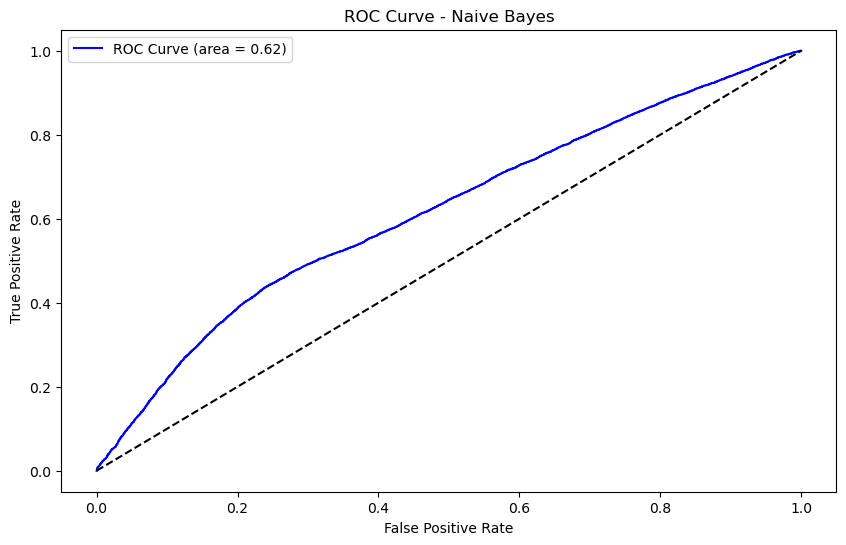

In [1018]:
fpr, tpr, _ = roc_curve(y_val, nb_model.predict_proba(X_val)[:, 1])
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--')  # קו אקראי
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes')
plt.legend(loc='best')
plt.show()

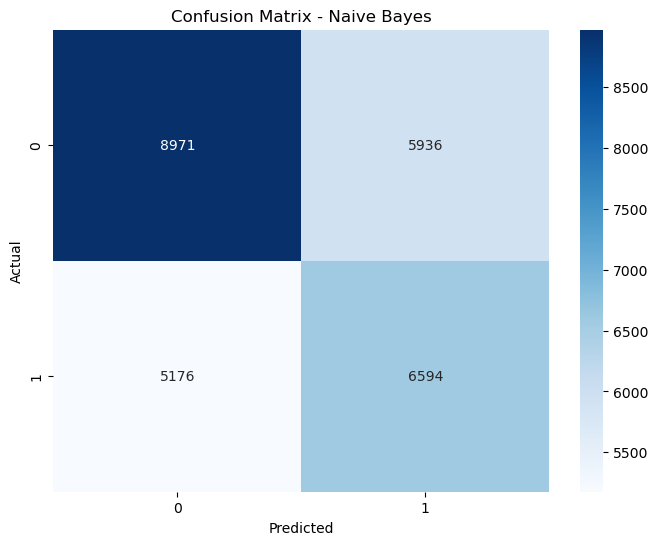

In [1019]:
conf_matrix = confusion_matrix(y_val, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

In [1020]:
y_test_pred_nb = nb_model.predict(X_test)

In [1021]:
accuracy_test = accuracy_score(y_test, y_test_pred_nb)
precision_test = precision_score(y_test, y_test_pred_nb)
recall_test = recall_score(y_test, y_test_pred_nb)
f1_test = f1_score(y_test, y_test_pred_nb)
roc_auc_test = roc_auc_score(y_test, nb_model.predict_proba(X_test)[:, 1])

In [1022]:
print("\n📊 **Naive Bayes - Test Metrics** 📊")
print(f"Accuracy: {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall: {recall_test:.4f}")
print(f"F1 Score: {f1_test:.4f}")
print(f"ROC AUC: {roc_auc_test:.4f}")


📊 **Naive Bayes - Test Metrics** 📊
Accuracy: 0.5884
Precision: 0.5365
Recall: 0.5695
F1 Score: 0.5525
ROC AUC: 0.6219


In [1023]:
y_test_proba_nb = nb_model.predict_proba(X_test)[:, 1]

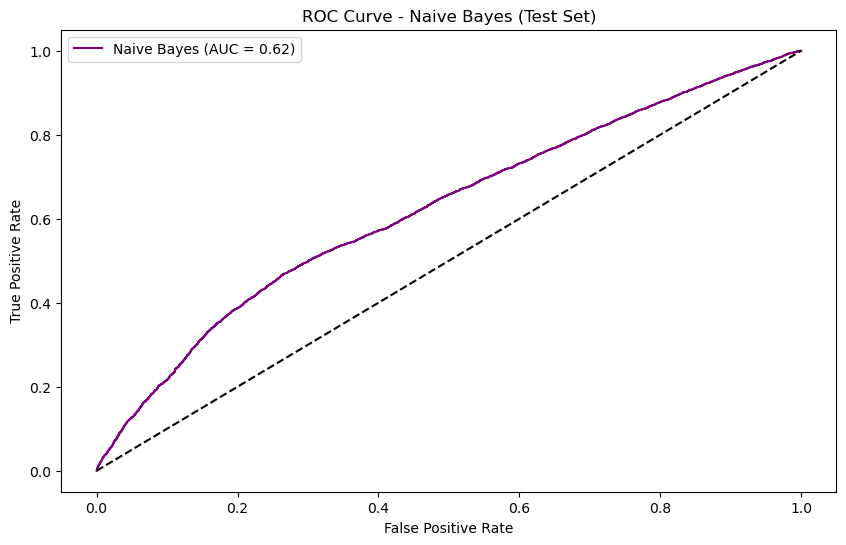

In [1024]:
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_test_proba_nb)
roc_auc_nb = roc_auc_score(y_test, y_test_proba_nb)

#ROC
plt.figure(figsize=(10, 6))
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})', color='purple')
plt.plot([0, 1], [0, 1], 'k--')  # קו אקראי
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Naive Bayes (Test Set)')
plt.legend(loc='best')
plt.show()

In [1025]:
y_test_pred_nb = nb_model.predict(X_test)

In [1026]:
#Creat confusion matrix:
conf_matrix_nb = confusion_matrix(y_test, y_test_pred_nb)

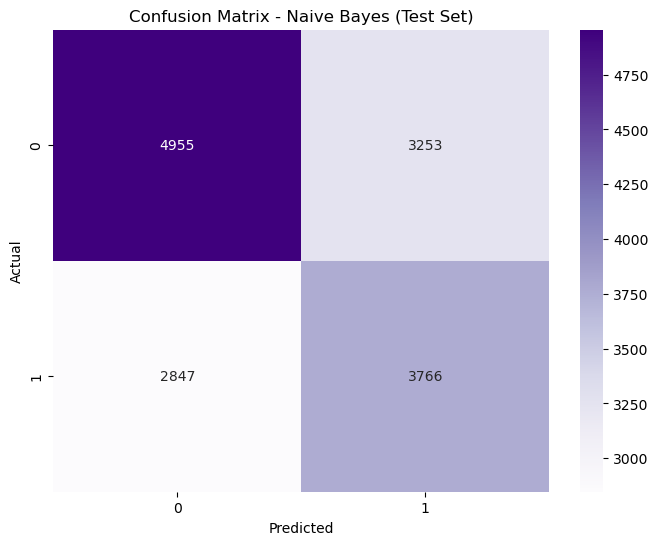

In [1027]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes (Test Set)')
plt.show()

Conclusions NB : 
Naïve Bayes assumes feature independence, which may not be realistic for shot prediction, where factors like defender distance and shot clock time are often correlated. 
While it may serve as a quick baseline model, more advanced models (like Random Forest or SVM) may be better suited for capturing complex interactions in basketball shot prediction.

## XGBOOST:
XGBoost (Extreme Gradient Boosting) is a powerful ensemble learning algorithm based on gradient boosting. It builds multiple decision trees sequentially, where each tree corrects the mistakes of the previous one, leading to highly accurate and robust predictions. XGBoost is known for its efficiency, scalability, and strong predictive performance in structured data tasks.

In [1030]:
!pip install xgboost

In [1031]:
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

In [1032]:
# Creat model XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,  
    learning_rate=0.1,  
    max_depth=6,  
    subsample=0.8, 
    colsample_bytree=0.8,
    random_state=42
)

In [1033]:
# Convert format:
X_train = X_train.values
X_val = X_val.values
X_test = X_test.values
y_train = y_train.values
y_val = y_val.values
y_test = y_test.values

In [1034]:
#Training the model XGBoost
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [1035]:
#Predict on training set
y_pred_xgb = xgb_model.predict(X_val)

In [1036]:
accuracy = accuracy_score(y_val, y_pred_xgb)
precision = precision_score(y_val, y_pred_xgb)
recall = recall_score(y_val, y_pred_xgb)
f1 = f1_score(y_val, y_pred_xgb)
roc_auc = roc_auc_score(y_val, xgb_model.predict_proba(X_val)[:, 1])
report = classification_report(y_val, y_pred_xgb)

In [1037]:
print("\n📊 **XGBoost - Metrics** 📊")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print('Classification Report:')
print(report)


📊 **XGBoost - Metrics** 📊
Accuracy: 0.6768
Precision: 0.7039
Recall: 0.4616
F1 Score: 0.5576
ROC AUC: 0.7289
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.85      0.75     14907
           1       0.70      0.46      0.56     11770

    accuracy                           0.68     26677
   macro avg       0.68      0.65      0.65     26677
weighted avg       0.68      0.68      0.66     26677



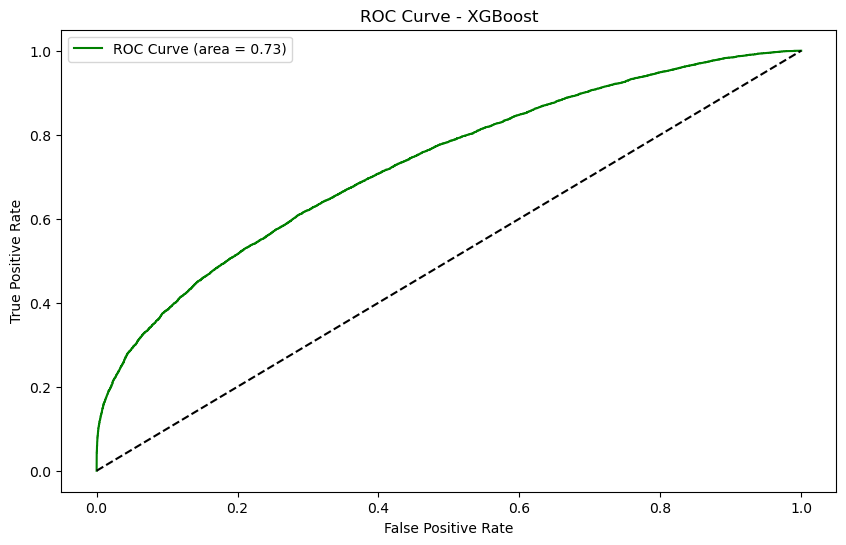

In [1038]:
fpr, tpr, _ = roc_curve(y_val, xgb_model.predict_proba(X_val)[:, 1])
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--')  # קו אקראי
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend(loc='best')
plt.show()

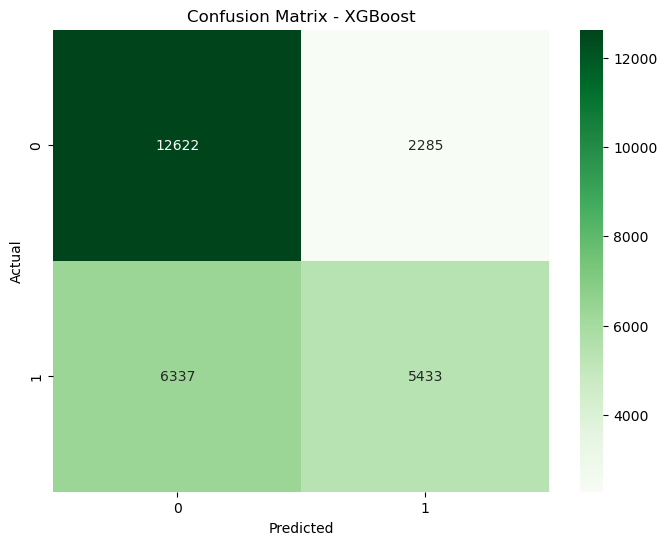

In [1039]:
conf_matrix = confusion_matrix(y_val, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

In [1040]:
y_test_pred_xgb = xgb_model.predict(X_test)

In [1041]:
y_test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [1042]:
accuracy_xgb = accuracy_score(y_test, y_test_pred_xgb)
precision_xgb = precision_score(y_test, y_test_pred_xgb)
recall_xgb = recall_score(y_test, y_test_pred_xgb)
f1_xgb = f1_score(y_test, y_test_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_test_proba_xgb)

In [1043]:
print("\n📊 **XGBoost - Test Set Metrics** 📊")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")
print(f"ROC AUC: {roc_auc_xgb:.4f}")


📊 **XGBoost - Test Set Metrics** 📊
Accuracy: 0.6736
Precision: 0.7029
Recall: 0.4650
F1 Score: 0.5597
ROC AUC: 0.7253


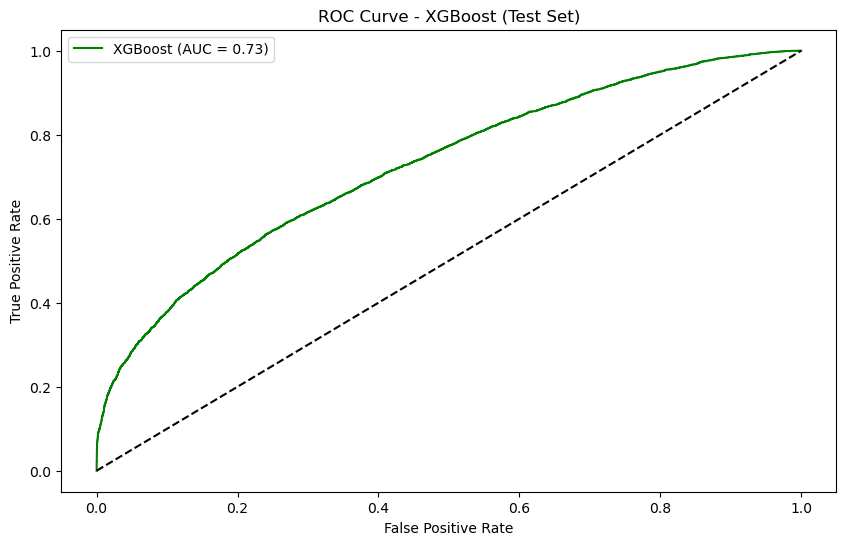

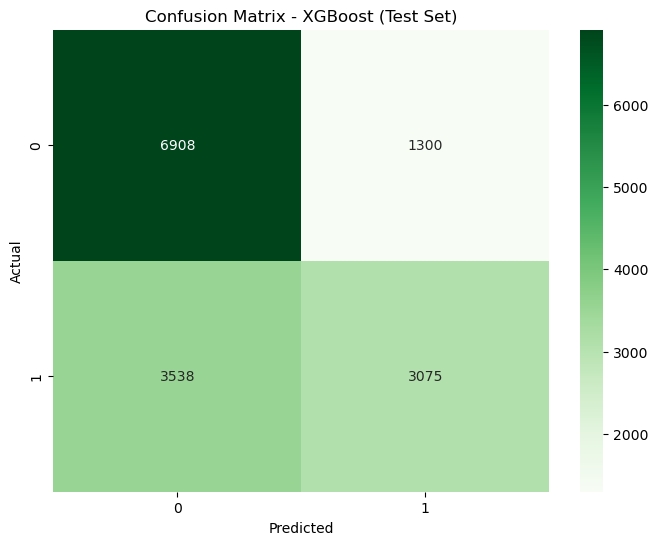

In [1044]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_proba_xgb)

plt.figure(figsize=(10, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})', color='green')
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost (Test Set)')
plt.legend(loc='best')
plt.show()

conf_matrix_xgb = confusion_matrix(y_test, y_test_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost (Test Set)')
plt.show()

Conclusions XGBOOST :

General conclusions :